# Summary

# 1. Performing computations

In [1]:
%config InlineBackend.figure_format = "retina"

import glob
import importlib
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

project_root = os.path.abspath(".")
scripts_dir = os.path.join(project_root, "scripts", "analysis")
sys.path.insert(0, scripts_dir)

import display as _display_helpers
import utils

# Reloaded before the from-imports below: `from utils import ...` binds the
# names of the module already in sys.modules, so reloading afterwards would
# leave every constant here pointing at the pre-edit object.
for _m in (utils, _display_helpers):
    importlib.reload(_m)

from utils import (
    CALLER_KEYS, CHROMHMM_DEFAULT, COSINE, FULL, FULL_DISPLAY,
    JACCARD, JACCARD_DISPLAY, JOINT_CHROMHMM, JOINT_HATCH, JOINT_KMEANS_HOMER,
    JOINT_KMEANS_MACS2, JOINT_KMEANS_OMNI, KAPPA, KMEANS_HOMER,
    KMEANS_MACS2, KMEANS_OMNI, NOQH, NOQH_DISPLAY, POINT_SIZE
)
from display import header, show_all

In [2]:
# Comparison parameters
COMPARISON_METRICS = [KAPPA, JACCARD]
COMPARISON_DOMAINS = [FULL, NOQH]

# Cosine is read off the same caches but lands on composition axes of its own
# instead of being averaged into the agreement ones, so the collectors ask for
# one metric column more than COMPARISON_METRICS names.
COLLECTED_METRICS = COMPARISON_METRICS + [COSINE]

# On the Full domain a composition cosine (utils.COMPOSITION) saturates at 1:
# Quies alone takes 70-90% of the genome, so it ranks the methods on the fourth
# decimal of their Quies budget. NOQH drops Quies and Het and compares the
# states the callers actually disagree about.
COSINE_DOMAINS = [FULL, NOQH]

# The cross-assay axes compare ChIP-seq against Mint-ChIP, whose reference
# markups share only 10 of 15 state names, so a name-based kappa or cosine
# ranks the callers by how much of the genome they keep inside the shared part
# of the two alphabets. analysis_encode.ipynb therefore caches those axes over
# raw states with remapping, where NOQH drops the Quiescent and
# heterochromatin states.
CROSS_ASSAY_DOMAINS = [FULL, NOQH]

# Every domain a collector has to open a cache for, cosine's included.
COLLECTED_DOMAINS = list(set(COMPARISON_DOMAINS + COSINE_DOMAINS))


def metric_domains(metric):
    """The comparison domains `metric` is collected and ranked in."""
    return (COSINE_DOMAINS if utils.normalize_metric(metric) == COSINE
            else COMPARISON_DOMAINS)


# Labels of the axes and of the evidence notes. The agreement axes average
# exactly COMPARISON_METRICS and never the cosine.
METRICS_SLASH_LABEL = " / ".join(utils.metric_display(m) for m in COMPARISON_METRICS)
METRICS_LABEL = " and ".join(utils.metric_display(m) for m in COMPARISON_METRICS)
DOMAINS_LABEL = " and ".join(utils.domain_display(d) for d in COMPARISON_DOMAINS)
COSINE_DOMAINS_LABEL = " and ".join(utils.domain_display(d) for d in COSINE_DOMAINS)
CROSS_ASSAY_DOMAINS_LABEL = " and ".join(utils.domain_display(d) for d in CROSS_ASSAY_DOMAINS)
print(f"  metrics {COMPARISON_METRICS} over {COMPARISON_DOMAINS}, "
      f"[{COSINE!r}] over {COSINE_DOMAINS}")

OUT = "out/summary"
os.makedirs(OUT, exist_ok=True)

  metrics ['kappa', 'jaccard'] over ['full', 'noqh'], ['cosine'] over ['full', 'noqh']


In [3]:
METHODS = [
    CHROMHMM_DEFAULT,
    KMEANS_HOMER,
    KMEANS_MACS2,
    KMEANS_OMNI,
    JOINT_CHROMHMM,
    JOINT_KMEANS_HOMER,
    JOINT_KMEANS_MACS2,
    JOINT_KMEANS_OMNI,
]

# The two families are ranked separately: the individual models have evidence
# on every axis, the joint ones only on the axes that need neither a comparison
# against a joint model nor an enrichment table. Every rank score below is also
# taken inside a family - see score_evidence().
def is_joint(method):
    """True for a joint model: the family a method is scored and ranked in."""
    return str(method).startswith("joint")


INDIVIDUAL_METHODS = [m for m in METHODS if not is_joint(m)]
JOINT_METHODS = [m for m in METHODS if is_joint(m)]


DATASETS = ["encode", "sagaconf", "epi1000"]

DATASET_NAMES = {"encode": "ENCODE", "sagaconf": "SAGAconf", "epi1000": "1000 epigenomes"}

AXES = {
    "replicates": (
        "Replicate\nagreement", "high", METRICS_SLASH_LABEL,
        f"Agreement between segmentations of biological replicates of the same "
        f"condition, averaged over {METRICS_LABEL} and {DOMAINS_LABEL}."),
    "replicates_cosine": (
        "Replicate\ncomposition", "high", "Cosine",
        f"Agreement of state composition between biological replicates, "
        f"measured by Cosine similarity over {COSINE_DOMAINS_LABEL}."),
    "replicates_emissions": (
        "Replicate emission\nsimilarity", "high", "cosine of the state emissions",
        "Similarity of the state signatures a method learns from the two "
        "replicates of a sample: the mean cosine of the emission vectors of "
        "the matched states, over the one-to-one matching of the two state "
        "spaces. Higher means the same biology is described by the same state "
        "definitions."),
    "cross_sample": (
        "Cross-sample\nagreement", "high", METRICS_SLASH_LABEL,
        f"Agreement between segmentations of different samples, averaged over "
        f"{METRICS_LABEL} and {DOMAINS_LABEL}."),
    "cross_sample_cosine": (
        "Cross-sample\ncomposition", "high", "Cosine",
        f"Agreement of state composition between different samples, "
        f"measured by Cosine similarity over {COSINE_DOMAINS_LABEL}."),
    "joint_indiv": (
        "Individual /\njoint agreement", "high", METRICS_SLASH_LABEL,
        f"Agreement of a sample segmented on its own with the same sample "
        f"segmented inside a joint model, averaged over {METRICS_LABEL} and "
        f"{DOMAINS_LABEL}."),
    "joint_indiv_cosine": (
        "Individual / joint\ncomposition agreement", "high", "Cosine",
        f"Agreement of state composition between individual and joint "
        f"segmentations, measured by Cosine similarity over {COSINE_DOMAINS_LABEL}."),
    "entropy": (
        "Low transition\ncomplexity", "low", "transition matrix entropy",
        "Entropy of the state transition matrix: how fragmented the "
        "segmentation is. Lower means fewer spurious state switches. "
        f"Collected once per comparison domain ({DOMAINS_LABEL}); each domain "
        f"is ranked only against itself."),
    "functional": (
        "Functional\ncorrespondence", "high", JACCARD_DISPLAY,
        "Overlap of the promoter, transcription and enhancer state families "
        "with independent annotations of the same sample - RefSeq TSS and gene "
        "bodies, the RNA-seq-expressed subset of both, and ATAC-seq peaks - "
        "measured by Jaccard similarity."),
    "state_fidelity": (
        "State-space\nfidelity", "high", "fraction reaching k=15",
        "Fraction of segmentations that actually realize the 15 requested "
        "states instead of collapsing some of them."),
    "segments_stability": (
        "Segment-count\nstability", "low", "CV of segment number",
        "Coefficient of variation of the number of segments across the "
        "samples of a dataset — how much the granularity drifts with input."),
    "cross_assay_agreement": (
        "Cross-assay\nagreement", "high", METRICS_SLASH_LABEL,
        f"Agreement between the ChIP-seq and the Mint-ChIP segmentations of a "
        f"caller, over every ChIP x Mint pair of samples, so it asks how much "
        f"agreement survives a change of assay and of cell type together. "
        f"Read on raw states using remapping to align the two vocabularies, "
        f"over {METRICS_LABEL} and "
        f"{CROSS_ASSAY_DOMAINS_LABEL}. The callers are ranked inside each pair "
        f"and those ranks averaged, since a caller whose Mint-ChIP model "
        f"collapsed has fewer usable pairs than the others."),
    "cross_assay_agreement_cosine": (
        "Cross-assay\ncomposition agreement", "high", "Cosine",
        f"Agreement of state composition between the ChIP-seq and the "
        f"Mint-ChIP segmentations of a caller, on the same rematched raw state "
        f"labels and pairs as the axis above and ranked inside each pair the "
        f"same way, measured by Cosine similarity "
        f"over {CROSS_ASSAY_DOMAINS_LABEL}."),
    "cross_assay_segments_stability": (
        "Cross-assay\ncounts stability", "low", "CV of segment number",
        "Coefficient of variation of the number of segments across ChIP-seq "
        "and Mint-ChIP experiments of the same sample."),
}

AXIS_ORDER = [
    "state_fidelity", "segments_stability",
    "entropy",
    "functional",
    "cross_sample", "cross_sample_cosine",
    "replicates", "replicates_cosine",
    "replicates_emissions",
    "cross_assay_segments_stability", "cross_assay_agreement", "cross_assay_agreement_cosine",
    "joint_indiv", "joint_indiv_cosine",
]

# Axes collected once per comparison domain (and per metric, where they compare
# two segmentations) so that no score mixes domains: every variant is ranked
# only against same-domain evidence, and axis_scores() averages the variants
# back into the main axis.
VARIANT_MAIN_AXES = ["replicates", "replicates_cosine",
                     "cross_sample", "cross_sample_cosine",
                     "joint_indiv", "joint_indiv_cosine",
                     "cross_assay_agreement", "cross_assay_agreement_cosine",
                     "entropy"]


def axis_variants(main):
    """The per-domain (and, for the agreement axes, per-metric) variants the
    main axis is built from."""
    if main == "entropy":
        return [f"entropy_{mode}" for mode in COMPARISON_DOMAINS]

    # The cross-assay axes are cached over rematched raw states, so they take
    # their domains from CROSS_ASSAY_DOMAINS.
    cross_assay = main.startswith("cross_assay_agreement")

    if main.endswith("_cosine"):
        base = main[:-len("_cosine")]
        domains = CROSS_ASSAY_DOMAINS if cross_assay else COSINE_DOMAINS
        return [f"{base}_{COSINE}_{mode}" for mode in domains]

    domains = CROSS_ASSAY_DOMAINS if cross_assay else COMPARISON_DOMAINS
    return [f"{main}_{m}_{mode}"
            for m in COMPARISON_METRICS for mode in domains]


# A variant that already names an existing axis is not registered twice.
VARIANT_AXES = []
for main in VARIANT_MAIN_AXES:
    for v in axis_variants(main):
        if v in AXES:
            continue
        AXES[v] = (v, AXES[main][1], AXES[main][2], "Variant for ranking")
        VARIANT_AXES.append(v)

ALL_AXIS_CATEGORIES = AXIS_ORDER + VARIANT_AXES

EVIDENCE_COLUMNS = ["Axis", "Dataset", "Cell", "Method", "Value", "N", "Note"]


def canonical(name):
    return utils.normalize_method(name)


def axis_label(axis, oneline=False):
    label = AXES[str(axis)][0]
    return label.replace("\n", " ") if oneline else label


WORKDIRS = {}
for dataset, config_file in [("encode", "config_encode.yaml"),
                             ("sagaconf", "config_sagaconf.yaml")]:
    with open(os.path.join(project_root, config_file)) as f:
        WORKDIRS[dataset] = yaml.safe_load(f)["workdir"]
WORKDIRS["epi1000"] = os.path.join(os.path.dirname(WORKDIRS["encode"]), "epi1000")

for dataset, workdir in WORKDIRS.items():
    present = os.path.isdir(os.path.join(os.path.expanduser(workdir), "out"))
    print(f"  {DATASET_NAMES[dataset]:16s} {workdir}"
          f"{'' if present else '   (no out/ — run its notebook first)'}")

  ENCODE           ~/data/2026_segmentations/encode
  SAGAconf         ~/data/2026_segmentations/sagaconf
  1000 epigenomes  ~/data/2026_segmentations/epi1000


In [4]:
pd.DataFrame([{"Axis": axis_label(a, oneline=True), "Metric": AXES[a][2],
               "Better": AXES[a][1], "What it measures": AXES[a][3]}
              for a in AXIS_ORDER])

,Axis,Metric,Better,What it measures
0,State-space fidelity,fraction reaching k=15,high,Fraction of segmentations that actually realiz...
1,Segment-count stability,CV of segment number,low,Coefficient of variation of the number of segm...
2,Low transition complexity,transition matrix entropy,low,Entropy of the state transition matrix: how fr...
3,Functional correspondence,Jaccard,high,"Overlap of the promoter, transcription and enh..."
4,Cross-sample agreement,Kappa / Jaccard,high,Agreement between segmentations of different s...
5,Cross-sample composition,Cosine,high,Agreement of state composition between differe...
6,Replicate agreement,Kappa / Jaccard,high,Agreement between segmentations of biological ...
7,Replicate composition,Cosine,high,Agreement of state composition between biologi...
8,Replicate emission similarity,cosine of the state emissions,high,Similarity of the state signatures a method le...
9,Cross-assay counts stability,CV of segment number,low,Coefficient of variation of the number of segm...


## Reading the caches into one evidence table

In [5]:
def _rows(axis, dataset, values, note, cell=None, n=None):
    return [{"Axis": axis, "Dataset": dataset, "Cell": cell or dataset,
             "Method": method, "Value": float(value), "Note": note,
             "N": (n or {}).get(method, np.nan)}
            for method, value in values.items()
            if method in METHODS and value is not None and not pd.isna(value)]


_SAID = set()


def _say_once(message):
    """Print `message` unless this run has already printed it: every cache is
    balanced once per metric and once per domain, but the imbalance is a
    property of the cache, so the same line would be printed four times."""
    if message not in _SAID:
        _SAID.add(message)
        print(message)


def _common_units(df, keys, unit_col, where):
    """`df` cut down to the comparison units every method in it has a value for.

    An axis averages a method over the units of its cell - a dataset, a pair of
    datasets, an epigenome - and then ranks the averages, so the averages have
    to cover the same units. Where the gate takes a segmentation out for one
    caller only, that caller would otherwise average the easier remainder: the
    ENCODE monocytes_mint pairs score lower for everyone, so leaving them out
    of the MACS2 mean alone lifts it above callers that beat MACS2 on every
    pair the two of them share."""
    units = df[unit_col].astype(str)
    per_method = {method: set(group) for method, group in units.groupby(keys)}
    if not per_method:
        return df, keys
    common = set.intersection(*per_method.values())
    dropped = sorted(set.union(*per_method.values()) - common)
    if dropped:
        _say_once(f"  {where}: {len(dropped)} of {len(dropped) + len(common)} "
                  f"comparison units are missing for at least one method and "
                  f"go for all of them, so the ranked averages cover the same "
                  f"units ({', '.join(dropped)})")
    keep = units.isin(common)
    return df[keep], keys[keep]


def _unit_ranks(df, keys, value_col, unit_col, where, high=True):
    """Mean within-unit rank score per method, and the unit count behind it.

    The way out of a unit set that is not the same for every method which gives
    up neither the unit nor the method: rank the methods inside each unit, which
    takes that unit's difficulty out of the number, then average those ranks
    over the units a method reached. For the ENCODE cross-assay axes, where
    _common_units() would throw away three of the six ChIP x Mint pairs and the
    only one that holds the biosample fixed. Inside a unit the two families are
    ranked apart, as score_evidence() does.

    The value is a mean rank score in [0, 1], not a mean of the metric.
    score_evidence() ranks it again, which is monotone and so reorders nothing,
    but the Value column of evidence.tsv reads as a rank and the Note says so.
    """
    frame = pd.DataFrame({"method": list(keys),
                          "unit": list(df[unit_col].astype(str)),
                          "value": list(df[value_col].astype(float))})
    units = frame["unit"].nunique()
    scores, alone = {}, 0
    for _, side in frame.groupby(["unit", frame["method"].map(is_joint)]):
        if len(side) < 2:
            alone += 1
            continue
        ranks = side["value"].rank(ascending=not high, method="average")
        for method, rank in zip(side["method"], ranks):
            scores.setdefault(method, []).append(
                (len(side) - rank) / (len(side) - 1))
    reached = frame.groupby("method")["unit"].nunique()
    partial = reached[reached < units]
    if len(partial):
        _say_once(f"  {where}: "
                  + ", ".join(f"{m} reached {n} of {units} comparison units"
                              for m, n in partial.items())
                  + " - the methods are ranked inside each unit and those "
                    "ranks averaged, so a unit one method missed costs "
                    "neither that method the axis nor the others the unit")
    if alone:
        _say_once(f"  {where}: {alone} comparison unit(s) carry a single model "
                  f"of its family, so they hold no ranking and are left out")
    return ({m: float(np.mean(v)) for m, v in scores.items()},
            {m: len(v) for m, v in scores.items()})


def _aggregate(df, method_col, value_col, mapper=canonical, unit_col=None,
               where=None, balance="units", high=True):
    """Mean and count of `value_col` per method.

    Pass `unit_col` for a cache that names the comparison unit behind each row,
    so that the means cover the same units for every method. `balance="units"`
    intersects the units of the methods (_common_units); `balance="ranks"`
    keeps both and returns mean within-unit ranks instead (_unit_ranks, which
    `high` tells the ranking direction). Without `unit_col` the means are taken
    over whatever rows survive, which is only safe where nothing can be missing
    for one method alone."""
    keys = df[method_col].map(mapper)
    keep = keys.notna() & df[value_col].notna()
    df, keys = df.loc[keep], keys[keep]
    if unit_col is None:
        grouped = df.groupby(keys)[value_col]
        return grouped.mean().to_dict(), grouped.size().to_dict()
    if balance == "ranks":
        return _unit_ranks(df, keys, value_col, unit_col, where, high=high)
    df, keys = _common_units(df, keys, unit_col, where)
    grouped = df.groupby(keys)[value_col]
    return grouped.mean().to_dict(), grouped.size().to_dict()


def _no_cache(where, what):
    print(f"  {where}: no {what}, that variant is omitted")


def _find_column(df, *candidates):
    """The first of `candidates` present among the columns of `df`, matched
    case-insensitively; None when the cache carries none of them."""
    lookup = {str(c).lower(): c for c in df.columns}
    for candidate in candidates:
        if candidate is not None and str(candidate).lower() in lookup:
            return lookup[str(candidate).lower()]
    return None


def _domain_rows(df, mode, where):
    """The rows of a long cache belonging to comparison domain `mode`. ENCODE
    and SAGAconf spell the Mode column 'Full'/'NOQH' while the 1000-epigenomes
    caches spell it 'FULL'/'NOQH', so utils.normalize_domain() does the match."""
    col = _find_column(df, "Mode")
    if col is None:
        _no_cache(where, "Mode column")
        return None
    modes = df[col].astype(str)
    rows = df[modes.map(utils.normalize_domain) == utils.normalize_domain(mode)]
    if rows.empty:
        _no_cache(where, f"{mode} rows (the cache has "
                         f"{sorted(modes.unique())})")
        return None
    return rows


def _metric_column(df, metric, where, mode=None):
    """The column holding `metric`, matched case-insensitively over every alias
    utils.metric_aliases() knows of. Pass `mode` for a wide cache that keeps one
    column per domain (kappa / kappa_noqh); leave it out when the domain lives
    in a Mode column instead."""
    spellings = utils.metric_aliases(metric)
    if mode is None or utils.normalize_domain(mode) == FULL:
        candidates = list(spellings)
    else:
        candidates = [f"{spelling}_{mode}" for spelling in spellings]
    col = _find_column(df, *candidates)
    if col is None:
        _no_cache(where, f"a {metric} column (looked for {candidates})")
    return col


def _metric_rows(rows, axis, mode, dataset, where, note, method_col="Method",
                 unit_col="Dataset", balance="units", gate=True, wide=False):
    """One `{axis}_{metric}_{mode}` variant per metric the domain is collected
    in, off the `mode` rows of a cache. `note` is the note prefix; `gate` off
    for a cache whose domains are fixed rather than per metric; `wide` for one
    that keeps a column per domain instead of a Mode column."""
    evidence = []
    for metric in COLLECTED_METRICS:
        if gate and mode not in metric_domains(metric):
            continue
        col = _metric_column(rows, metric, where, mode if wide else None)
        if col is None:
            continue
        values, counts = _aggregate(rows, method_col, col, unit_col=unit_col,
                                    where=where, balance=balance)
        evidence += _rows(f"{axis}_{metric}_{mode}", dataset, values,
                          f"{note} ({utils.metric_display(metric)}, "
                          f"{utils.domain_display(mode)})", n=counts)
    return evidence


def _long_cache_rows(df, axis, dataset, where, note, domains=None, **kwargs):
    """The evidence of a long cache that carries the domain in a Mode column."""
    evidence = []
    for mode in domains or COLLECTED_DOMAINS:
        rows = _domain_rows(df, mode, where)
        if rows is not None:
            evidence += _metric_rows(rows, axis, mode, dataset, where, note,
                                     **kwargs)
    return evidence


def _cv(values):
    values = np.asarray([v for v in values if v is not None and not pd.isna(v)],
                        dtype=float)
    if len(values) < 2 or values.mean() == 0:
        return np.nan
    return float(values.std(ddof=1) / values.mean())


def _segments_stability(dataset, df, method_col, segments_col, cell=None,
                        unit_col=None, where=None):
    keys = df[method_col].map(canonical)
    keep = keys.notna()
    df, keys = df.loc[keep], keys[keep]
    if unit_col is not None:
        df, keys = _common_units(df, keys, unit_col, where)
    grouped = df.groupby(keys)[segments_col]
    values = {method: _cv(group.values) for method, group in grouped}
    return _rows("segments_stability", dataset, values, cell=cell,
                 note=f"CV of the segment number over {len(df)} "
                      f"segmentations", n=grouped.size().to_dict())


def _replicate_emissions(out, datasets):
    """rep1-vs-rep2 emission similarity of every method, one row per dataset.

    Read from the per-dataset all-pairs comparison tables, since no notebook
    aggregates the emission cosine into a cache of its own. A joint model is
    only compared in the joint/ table, so both tables are read and a method
    reached by either one is kept once."""
    frames = []
    for ds in datasets:
        for rel in ("matched/comparison_all_pairs.tsv",
                    "matched/joint/comparison_all_pairs.tsv"):
            path = f"{out}/{ds}/{rel}"
            if not os.path.exists(path):
                continue
            df = _read(path)
            if df is None or utils.EMISSION not in df.columns:
                continue
            seg1, seg2 = df["seg1"].astype(str), df["seg2"].astype(str)
            pairs = [utils.is_replicate(a) and utils.should_compare(a, b)
                     for a, b in zip(seg1, seg2)]
            rows = df[pairs].dropna(subset=[utils.EMISSION])
            if rows.empty:
                continue
            frames.append(pd.DataFrame({
                "Dataset": ds,
                # Both replicate suffixes are five characters, so the method is
                # the label of either side with its suffix dropped.
                "Method": rows["seg1"].astype(str).str[:-len("_rep1")],
                utils.EMISSION: rows[utils.EMISSION].astype(float),
            }))
    if not frames:
        return None
    return (pd.concat(frames, ignore_index=True)
            .drop_duplicates(subset=["Dataset", "Method"]))


def _emission_rows(dataset, out, datasets, excluded, where):
    """The emission similarity evidence of one dataset, empty when uncached."""
    emissions = _drop_excluded(_replicate_emissions(out, datasets), excluded)
    if emissions is None or emissions.empty:
        _no_cache(where, f"{utils.EMISSION} in the all-pairs comparison "
                         f"tables")
        return []
    values, counts = _aggregate(emissions, "Method", utils.EMISSION,
                                unit_col="Dataset",
                                where=f"{where} all-pairs comparison tables")
    return _rows("replicates_emissions", dataset, values,
                 f"rep1 vs rep2 cosine of the matched state emission vectors, "
                 f"over {len(emissions)} segmentation pairs", n=counts)


def _read(path, **kwargs):
    if not os.path.exists(path):
        print(f"  missing {path}")
        return None
    if path.endswith(".pkl"):
        return pd.read_pickle(path)
    sep = "\t" if path.endswith(".tsv") else ","
    return pd.read_csv(path, sep=sep, **kwargs)

In [6]:
ENCODE_DATASETS = ["imr90", "monocytes", "monocytes_mint", "gm12878_mint", "spleen"]
SAGACONF_DATASETS = ["mcf7", "gm12878", "k562", "cd14_monocyte", "hela_s3"]

PROMOTER_STATES = ["Tss", "TssFlnk", "TssFlnkU", "TssFlnkD"]
TX_STATES = ["Tx", "TxWk"]
ENHANCER_STATES = ["Enh", "Enh1", "Enh2", "EnhG", "EnhG1", "EnhG2", "EnhLo"]

FUNCTIONAL_TARGETS = [
    ("Promoter states vs RefSeq TSS", PROMOTER_STATES, "RefSeqTSS2kb"),
    ("Promoter states vs expressed TSS", PROMOTER_STATES, "ExpressedTSS2kb"),
    ("Transcription states vs RefSeq genes", TX_STATES, "RefSeqGene"),
    ("Transcription states vs expressed genes", TX_STATES, "ExpressedGeneBodies"),
    ("Active states vs ATAC-seq", PROMOTER_STATES + ENHANCER_STATES, "atac_"),
]


def _scope(segmentation):
    return "replicates" if str(segmentation).endswith(("_rep1", "_rep2")) else "pooled"


def _encode_frames(out, filename, columns, datasets=ENCODE_DATASETS, label="encode"):
    frames = []
    for ds in datasets:
        for rel in (f"matched/{filename}", f"matched/joint/{filename}"):
            df = _read(f"{out}/{ds}/{rel}")
            if df is None:
                continue
            df = df.copy()
            df["Method"] = (df["segmentation"].astype(str)
                            .str.replace(r"_rep\d$", "", regex=True))
            df["Dataset"] = ds
            df["Cell"] = f"{label}:" + df["segmentation"].map(_scope)
            df["Segmentation"] = ds + ":" + df["segmentation"].astype(str)
            frames.append(df[["Dataset", "Segmentation", "Method", "Cell"] + columns])
    if not frames:
        return None
    return (pd.concat(frames, ignore_index=True)
            .drop_duplicates(subset=["Segmentation"]))


# The states a model is asked for. A segmentation that realizes fewer has
# collapsed: it still covers the genome, so the coverage test below cannot see
# it, but a 2-state model scores an exact 0 kappa and 0 cosine against anything
# on the non-background domain, and that 0 is an artefact of the collapse.
N_STATES = 15

INCOMPLETE_COLUMNS = ["Dataset", "Segmentation", "Method", "n_states",
                      "Covered_bp", "Share", "Reason"]


def no_incomplete():
    """The empty unusable-segmentations frame, for a dataset with no gate."""
    return pd.DataFrame(columns=INCOMPLETE_COLUMNS)


def incomplete_segmentations(workdir, datasets=ENCODE_DATASETS, label="encode",
                             min_share=0.5, min_states=N_STATES):
    """The segmentations of `datasets` no comparison should be read off.

    Two ways a run comes out unusable, neither visible in the agreement caches:
    it covers a fraction of what the rest of its dataset covers, which is a
    truncated run (the joint ChromHMM of ENCODE spleen covers 11 Mb of 3.1 Gb),
    or it collapsed to fewer than `min_states` states, which leaves the
    non-background domain empty (the MACS2 KMeans of monocytes_mint has 2)."""
    out = os.path.join(os.path.expanduser(workdir), "out")
    stats = _encode_frames(out, "segment_stats.tsv",
                          ["n_states", "n_segments", "mean_length"],
                          datasets=datasets, label=label)
    if stats is None:
        return no_incomplete()
    stats = stats.assign(Covered_bp=stats["n_segments"] * stats["mean_length"])
    median = stats.groupby("Dataset")["Covered_bp"].transform("median")
    stats["Share"] = stats["Covered_bp"] / median
    truncated = stats["Share"] < min_share
    collapsed = stats["n_states"] < min_states
    bad = stats[truncated | collapsed].copy()
    reasons = []
    for share, n_states in zip(bad["Share"], bad["n_states"]):
        why = []
        if share < min_share:
            why.append(f"covers {share:.2%} of the dataset median")
        if n_states < min_states:
            why.append(f"{int(n_states)} of {min_states} states")
        reasons.append(", ".join(why))
    bad["Reason"] = reasons
    bad["Method"] = bad["Method"].map(canonical)
    return bad[INCOMPLETE_COLUMNS]


def _excluded_pairs(incomplete):
    reasons = dict(zip(zip(incomplete["Dataset"], incomplete["Method"]),
                       incomplete["Reason"]))
    pairs = {(ds, method)
             for ds, method in zip(incomplete["Dataset"], incomplete["Method"])
             if method is not None}
    if pairs:
        print("  excluding unusable segmentations: "
              + ", ".join(f"{ds}/{m} ({reasons[(ds, m)]})"
                          for ds, m in sorted(pairs)))
    return pairs


def _excluded_comparisons(pairs):
    return {(ds, key) for ds, method in pairs
            for key in CALLER_KEYS.get(utils.caller_key(method), (method,))}


def _drop_excluded(df, excluded, method_col="Method", dataset_cols=("Dataset",)):
    """`df` without the rows that name an excluded (dataset, method) pair.

    A dataset cell names one segmentation ("imr90"), a segmentation and its
    replicate ("imr90/rep1") or both sides of a comparison ("mcf7/gm12878"), so
    every "/"-separated part is tested: a pair goes when either of its sides is
    excluded. Pass `dataset_cols` for a cache that keeps the two sides in
    columns of their own (ds_a / ds_b)."""
    if not excluded or df is None or df.empty:
        return df
    methods = df[method_col].map(canonical)
    keep = np.ones(len(df), dtype=bool)
    for col in dataset_cols:
        sides = df[col].astype(str).str.split("/")
        keep &= np.array([not any((side, m) in excluded for side in row)
                          for row, m in zip(sides, methods)])
    return df[keep]


def _union_enrichment(dirpath, states, prefix):
    enrich = _read(f"{dirpath}/enrichment/enrichment.tsv")
    report = _read(f"{dirpath}/report.tsv")
    if enrich is None or report is None:
        return []
    sizes = report.set_index("state")["total_bp"]
    genome = sizes.sum()
    rows = []
    for label, group in enrich.groupby("label"):
        if not str(label).startswith(prefix):
            continue
        positive = group[group["fold_enrichment"] > 0]
        if positive.empty:
            continue
        annotation = float(np.median(positive["coverage"]
                                     / positive["fold_enrichment"])) * genome
        family = group[group["state"].isin(states)]
        family_bp = float(sizes.reindex(family["state"]).sum())
        if annotation <= 0 or family_bp <= 0:
            continue
        overlap = float((family["coverage"].values
                         * sizes.reindex(family["state"]).values).sum())
        rows.append({"Label": label,
                     JACCARD: overlap / (family_bp + annotation - overlap)})
    return rows


def _encode_functional(out):
    rows = []
    for path in sorted(glob.glob(f"{out}/*/matched/*/report.tsv")):
        dirpath = os.path.dirname(path)
        parts = dirpath.split(os.sep)
        ds, method = parts[-3], canonical(parts[-1])
        if method is None:
            continue
        for target, states, prefix in FUNCTIONAL_TARGETS:
            for row in _union_enrichment(dirpath, states, prefix):
                rows.append({"Dataset": ds, "Method": method, "Target": target,
                             "Cell": f"encode:{target}", **row})
    return pd.DataFrame(rows) if rows else None


def collect_encode(workdir):
    out = os.path.join(os.path.expanduser(workdir), "out")
    print(f"ENCODE caches in {out}")
    evidence = []
    incomplete = incomplete_segmentations(workdir)
    excluded = _excluded_pairs(incomplete)

    rep = _read(f"{out}/df_joint_rep.pkl")
    if rep is not None:
        evidence += _long_cache_rows(
            _drop_excluded(rep, excluded), "replicates", "encode",
            "ENCODE df_joint_rep.pkl", "rep1 vs rep2")

    evidence += _emission_rows("encode", out, ENCODE_DATASETS, excluded,
                               "ENCODE")

    pairs = _read(f"{out}/comparison_table.tsv")
    if pairs is not None:
        # Same-assay pairs only: comparison_table.tsv is built off the
        # name-matched matrices, so its ChIP x Mint-ChIP rows compare two state
        # vocabularies that do not line up - the comparison the cross-assay
        # axes below read off rematched raw state labels instead.
        mint_a = pairs["ds_a"].astype(str).str.endswith("_mint")
        mint_b = pairs["ds_b"].astype(str).str.endswith("_mint")
        same_assay = mint_a == mint_b
        if not same_assay.all():
            print(f"  ENCODE comparison_table.tsv: {int((~same_assay).sum())} of "
                  f"{len(pairs)} rows are ChIP x Mint-ChIP pairs, left to the "
                  f"cross-assay axes")
        pairs = pairs[same_assay]
        # ds_a / ds_b rather than one Dataset column, and a lowercase method.
        pairs = _drop_excluded(pairs, excluded, method_col="method",
                               dataset_cols=("ds_a", "ds_b"))
        pairs = pairs.assign(Pair=pairs["ds_a"].astype(str) + "/"
                                  + pairs["ds_b"].astype(str))
        # One metric column per domain rather than a Mode column.
        for mode in COLLECTED_DOMAINS:
            evidence += _metric_rows(
                pairs, "cross_sample", mode, "encode",
                "ENCODE comparison_table.tsv", "all same-assay pairs",
                method_col="method", unit_col="Pair", wide=True)

    # Cross-assay (ChIP vs Mint-ChIP) agreement, off its own cache: the ChIP x
    # Mint rows of comparison_table.tsv compare the two assays by state name,
    # which the two references do not share, while this cache rematches their
    # raw state labels before comparing them. Ranked inside each pair rather
    # than averaged over a pair set that is not the same for every caller -
    # see _unit_ranks().
    cross_assay = _drop_excluded(_read(f"{out}/df_cross_assay.pkl"), excluded)
    if cross_assay is None:
        _no_cache("ENCODE", "df_cross_assay.pkl (run the cross-assay section "
                            "of analysis_encode.ipynb)")
    else:
        evidence += _long_cache_rows(
            cross_assay, "cross_assay_agreement", "encode",
            "ENCODE df_cross_assay.pkl",
            "mean rank among the callers of each ChIP vs Mint-ChIP pair, on "
            "rematched raw states",
            domains=CROSS_ASSAY_DOMAINS, gate=False, balance="ranks")

    joint = _read(f"{out}/df_joint_indiv.pkl")
    if joint is not None:
        evidence += _long_cache_rows(
            _drop_excluded(joint, _excluded_comparisons(excluded)),
            "joint_indiv", "encode", "ENCODE df_joint_indiv.pkl",
            "individual vs joint")

    for mode in COMPARISON_DOMAINS:
        suffix = "" if mode == FULL else f"_{mode}"
        entropy = _drop_excluded(
            _encode_frames(out, f"entropy_summary{suffix}.tsv", ["total_entropy"]),
            excluded)
        if entropy is None:
            _no_cache("ENCODE", f"entropy_summary{suffix}.tsv "
                                f"({utils.domain_display(mode)} transition matrix entropy)")
            continue
        for cell, group in entropy.groupby("Cell"):
            values, counts = _aggregate(
                group, "Method", "total_entropy", unit_col="Dataset",
                where=f"ENCODE entropy_summary{suffix}.tsv ({cell})")
            evidence += _rows(f"entropy_{mode}", "encode", values,
                              f"{utils.domain_display(mode)} transition matrix entropy of the "
                              f"{cell} segmentations", cell=cell, n=counts)

    functional = _drop_excluded(_encode_functional(out), excluded)
    if functional is not None:
        for cell, group in functional.groupby("Cell"):
            values, counts = _aggregate(group, "Method", JACCARD,
                                        mapper=lambda m: m,
                                        unit_col="Dataset",
                                        where=f"ENCODE enrichment ({cell})")
            datasets = ", ".join(sorted(group["Dataset"].unique()))
            evidence += _rows("functional", "encode", values,
                              f"{JACCARD_DISPLAY} of the state family with the assay in "
                              f"{datasets}; the joint models have no enrichment "
                              f"tables", cell=cell, n=counts)

    all_segments = _encode_frames(out, "segment_stats.tsv",
                                  ["n_states", "n_segments"])
    if all_segments is not None:
        # Scored before the gate: this axis measures exactly the collapse the
        # gate excludes for, so filtering first would read it as a clean sweep.
        fidelity = all_segments.assign(
            ok=all_segments["n_states"].eq(N_STATES).astype(float))
        for cell, group in fidelity.groupby("Cell"):
            values, counts = _aggregate(
                group, "Method", "ok", unit_col="Dataset",
                where=f"ENCODE segment_stats.tsv fidelity ({cell})")
            evidence += _rows("state_fidelity", "encode", values,
                              f"fraction of the {cell} segmentations realizing "
                              f"{N_STATES} states", cell=cell, n=counts)

    segments = _drop_excluded(all_segments, excluded)
    if segments is not None:
        for cell, group in segments.groupby("Cell"):
            evidence += _segments_stability(
                "encode", group, "Method", "n_segments", cell=cell,
                unit_col="Dataset",
                where=f"ENCODE segment_stats.tsv stability ({cell})")
            # Cross-assay (ChIP vs Mint-ChIP) stability, over the datasets that
            # exist in both assays. One value per side, so that a pair is a CV
            # of a ChIP against a Mint number and of nothing else: taking the
            # two n_segments of whatever rows the pair matched would measure
            # rep1 vs rep2 of the ChIP side wherever the Mint side has no
            # segmentation in this scope.
            chip_dss = [ds for ds in ENCODE_DATASETS if not ds.endswith("_mint")]
            mint_dss = [ds for ds in ENCODE_DATASETS if ds.endswith("_mint")]
            pairs_dss = [(ds, f"{ds}_mint") for ds in chip_dss if f"{ds}_mint" in mint_dss]
            if pairs_dss:
                counts_by = (group[group["Method"].isin(METHODS)]
                             .groupby(["Method", "Dataset"])["n_segments"].mean())
                callers = [m for m in counts_by.index.get_level_values(0).unique()
                           if not str(m).startswith("joint")]
                # ENCODE has exactly one ChIP / Mint biosample pair and MACS2
                # has no usable segmentation on its Mint side, so the axis is
                # dropped: scoring three callers of four would credit them for
                # an axis MACS2 is neither credited nor charged for, and one
                # unit is too few to carry an axis anyway.
                usable = [pair for pair in pairs_dss
                          if all((m, ds) in counts_by.index
                                 for m in callers for ds in pair)]
                for pair in pairs_dss:
                    if pair not in usable:
                        _say_once(f"  ENCODE cross-assay counts stability "
                                  f"({cell}): {pair[0]} vs {pair[1]} is the "
                                  f"only pair of the axis and is not usable "
                                  f"for every caller, so the axis is dropped")
                if usable and callers:
                    res_values = {
                        m: float(np.mean([_cv([counts_by[(m, ds)] for ds in pair])
                                          for pair in usable]))
                        for m in callers}
                    res_counts = {m: len(usable) for m in callers}
                    pairs_label = ", ".join(f"{a} vs {b}" for a, b in usable)
                    evidence += _rows("cross_assay_segments_stability", "encode", res_values,
                                      f"CV of the segment number between the two assays "
                                      f"({pairs_label})", cell=cell, n=res_counts)
    return evidence, incomplete

In [7]:
def collect_sagaconf(workdir):
    out = os.path.join(os.path.expanduser(workdir), "out")
    print(f"SAGAconf caches in {out}")
    evidence = []
    incomplete = incomplete_segmentations(workdir, datasets=SAGACONF_DATASETS,
                                          label="sagaconf")
    excluded = _excluded_pairs(incomplete)

    def rows_of(axis, caches, label, note, drop):
        """analysis_sagaconf.ipynb keeps the two comparison domains in separate
        pickles instead of a Mode column, so the domain comes from the file
        name. The Full caches compare the two state spaces by state name, the
        NOQH ones reduce both sides to interpreted state types first and drop
        the background trio."""
        collected = []
        for mode in COLLECTED_DOMAINS:
            cache = caches.get(mode)
            df = _read(f"{out}/{cache}") if cache else None
            if df is None:
                _no_cache("SAGAconf", f"{utils.domain_display(mode)} {label} "
                                      f"({cache or 'no cache for this domain'})")
                continue
            collected += _metric_rows(_drop_excluded(df, drop), axis, mode,
                                      "sagaconf", f"SAGAconf {cache}", note)
        return collected

    evidence += rows_of("replicates",
                        {FULL: "df_rep.pkl", NOQH: "df_rep_noqh.pkl"},
                        "replicate agreement", "rep1 vs rep2", excluded)

    evidence += _emission_rows("sagaconf", out, SAGACONF_DATASETS, excluded,
                               "SAGAconf")

    # The two cell lines of a pair were matched to different joint models, so
    # df_cross_sample.pkl is the one SAGAconf cache built with rematch=True: it
    # realigns the two state spaces by emission cosine before comparing them by
    # name. That realignment used to scatter the quiescent states, which left
    # MACS2 KMeans with a Full composition cosine of 0.005 - see
    # match.background_augmented(), which fixed it.
    evidence += rows_of("cross_sample",
                        {FULL: "df_cross_sample.pkl",
                         NOQH: "df_cross_sample_noqh.pkl"},
                        "cross-sample agreement", "all cell-line pairs",
                        excluded)

    evidence += rows_of("joint_indiv",
                        {FULL: "df_ji.pkl", NOQH: "df_ji_noqh.pkl"},
                        "individual vs joint agreement", "individual vs joint",
                        _excluded_comparisons(excluded))

    # analysis_sagaconf.ipynb aggregates with skip_noqh=True, so only the Full
    # domain is cached; a NOQH run would write df_entropy_noqh.pkl and land here.
    ENTROPY_CACHES = {FULL: "df_entropy.pkl", NOQH: "df_entropy_noqh.pkl"}
    for mode in COMPARISON_DOMAINS:
        cache = ENTROPY_CACHES.get(mode)
        entropy = _read(f"{out}/{cache}") if cache else None
        if entropy is None:
            print(f"  no {utils.domain_display(mode)} transition matrix entropy for SAGAconf "
                  f"(analysis_sagaconf.ipynb runs compare with skip_noqh=True); "
                  f"the entropy_{mode} variant omits it")
            continue
        entropy = _drop_excluded(entropy, excluded)
        values, counts = _aggregate(entropy, "Method", "total_entropy",
                                    unit_col="Dataset",
                                    where=f"SAGAconf {cache}")
        evidence += _rows(f"entropy_{mode}", "sagaconf", values,
                          f"{utils.domain_display(mode)} transition matrix entropy, "
                          f"5 cell lines x 2 replicates", n=counts)

    segments = _read(f"{out}/df_segs.pkl")
    if segments is not None:
        # Before the gate, as in collect_encode().
        fidelity = segments.assign(
            ok=segments["n_states"].eq(N_STATES).astype(float))
        values, counts = _aggregate(fidelity, "Method", "ok",
                                    unit_col="Dataset",
                                    where="SAGAconf df_segs.pkl fidelity")
        evidence += _rows("state_fidelity", "sagaconf", values,
                          f"fraction of the 5 cell lines x 2 replicates realizing "
                          f"{N_STATES} states", n=counts)
        evidence += _segments_stability("sagaconf",
                                        _drop_excluded(segments, excluded),
                                        "Method", "n_segments",
                                        unit_col="Dataset",
                                        where="SAGAconf df_segs.pkl stability")
    return evidence, incomplete


# The published Roadmap 15-state segmentations the 1000-epigenomes caches carry
# next to the de-novo models, as analysis_epi1000.ipynb labels them in the
# replicate caches. Only the joint one is kept, as joint_chromhmm's evidence:
# there is no de-novo joint ChromHMM here, and a ChromHMM trained over every
# epigenome at once is what that method key means. The individual one is
# dropped rather than folded into chromhmm_default, which is the de-novo
# default-binarization model and not the published segmentation - and
# normalize_method() maps both spellings onto the same key, so folding it in
# put two differently produced segmentations behind one number at N=44.
EPI1000_REF_INDIV_LABELS = ("ref 15", "individual", "ref_15")


def _drop_reference_indiv(df, where, col="Method"):
    """`df` without the rows of the published individual 15-state model, for a
    cache that carries the de-novo methods too and so labels it by name."""
    if df is None:
        return None
    is_ref = df[col].astype(str).str.strip().str.lower().isin(EPI1000_REF_INDIV_LABELS)
    if is_ref.any():
        print(f"  {where}: {int(is_ref.sum())} published individual 15-state rows "
              f"dropped, they are not the de-novo {CHROMHMM_DEFAULT}")
    return df[~is_ref]


def _reference_joint_only(df, where, col="Method"):
    """The `joint_chromhmm` rows of a cache holding only the reference models.

    df_pw_15.csv and the 15-state stats caches relabel both published models
    with display_name(), so their individual one cannot be told from a de-novo
    Default ChromHMM by name — it is selected out by canonical key instead."""
    if df is None:
        return None
    keep = df[col].map(canonical) == JOINT_CHROMHMM
    if not keep.all():
        print(f"  {where}: {int((~keep).sum())} published individual 15-state "
              f"rows dropped, {int(keep.sum())} joint ones kept as "
              f"{JOINT_CHROMHMM}")
    return df[keep]


def _cross_sample_epi1000(out):
    # One cache per method, named after the display name of the method by an
    # earlier run of analysis_epi1000.ipynb and after its key by the current
    # one, so the same pairs can sit in out/ twice. Both would be averaged as
    # if they were independent pairs, so only the newest cache of each method
    # is read.
    by_method = {}
    for path in sorted(glob.glob(f"{out}/pw_cache_*.pkl")):
        cache = pd.read_pickle(path)
        df = cache.get("df") if isinstance(cache, dict) else None
        if df is None or df.empty:
            continue
        key = canonical(df["Method"].iloc[0])
        if key is None:
            continue
        previous = by_method.get(key)
        if previous is None or os.path.getmtime(path) > os.path.getmtime(previous[0]):
            by_method[key] = (path, df)
        if previous is not None:
            ignored = min([previous[0], path], key=os.path.getmtime)
            print(f"  1000 epigenomes: {os.path.basename(ignored)} is an older "
                  f"copy of the {key} pairs, ignored")
    frames = [df for _, df in by_method.values()]

    df_15 = _reference_joint_only(_read(f"{out}/df_pw_15.csv"),
                                  "1000 epigenomes df_pw_15.csv")
    if df_15 is not None and not df_15.empty:
        frames.append(df_15)

    if not frames:
        print(f"  missing {out}/pw_cache_*.pkl")
        return None
    return pd.concat(frames, ignore_index=True)


def collect_epi1000(workdir):
    out = os.path.join(os.path.expanduser(workdir), "out")
    print(f"1000-epigenomes caches in {out}")
    evidence = []

    rep = _drop_reference_indiv(_read(f"{out}/df_replicates.csv"),
                                "1000 epigenomes df_replicates.csv")
    if rep is not None:
        # The replicate pair is the comparison unit here, spelled over two
        # columns rather than one, so name it for _common_units().
        rep = rep.assign(Pair=rep["EID1"].astype(str) + "/"
                              + rep["EID2"].astype(str))
        evidence += _long_cache_rows(rep, "replicates", "epi1000",
                                     "1000 epigenomes df_replicates.csv",
                                     "rep1 vs rep2", unit_col="Pair")

    pairs = _cross_sample_epi1000(out)
    if pairs is not None:
        # The only axis with no unit balancing: pw_cache_*.pkl keeps Method,
        # Mode and the metrics and nothing else, so its sampled pairs cannot be
        # named, let alone intersected across the methods.
        print("  1000 epigenomes: the cross-sample caches carry no pair "
              "identity, so the sampled pairs behind each method's mean are "
              "not checked to be the same ones")
        evidence += _long_cache_rows(pairs, "cross_sample", "epi1000",
                                     "1000 epigenomes pw_cache_*.pkl",
                                     "sampled pairs", unit_col=None)

    joint = _read(f"{out}/df_joint_indiv_comparison.csv")
    if joint is not None:
        evidence += _long_cache_rows(
            joint, "joint_indiv", "epi1000",
            "1000 epigenomes df_joint_indiv_comparison.csv",
            "individual vs joint")

    emissions = _drop_reference_indiv(
        _read(f"{out}/df_replicates_emissions.csv"),
        "1000 epigenomes df_replicates_emissions.csv")
    if emissions is None:
        _no_cache("1000 epigenomes", "df_replicates_emissions.csv (run the "
                                     "replicate emission similarity cell)")
    else:
        col = _find_column(emissions, utils.EMISSION, utils.EMISSION_DISPLAY)
        if col is None:
            _no_cache("1000 epigenomes", f"a {utils.EMISSION} column")
        else:
            emissions = emissions.assign(
                Pair=emissions["EID1"].astype(str) + "/"
                     + emissions["EID2"].astype(str))
            values, counts = _aggregate(
                emissions, "Method", col, unit_col="Pair",
                where="1000 epigenomes df_replicates_emissions.csv")
            evidence += _rows("replicates_emissions", "epi1000", values,
                              f"rep1 vs rep2 cosine of the matched state "
                              f"emission vectors, over {len(emissions)} "
                              f"replicate pairs", n=counts)

    results = _read(f"{out}/df_results.csv")
    entropy_15 = _reference_joint_only(_read(f"{out}/df_entropy_15.csv"),
                                       "1000 epigenomes df_entropy_15.csv")
    segments_15 = _reference_joint_only(_read(f"{out}/df_segments_15.csv"),
                                        "1000 epigenomes df_segments_15.csv")
    if entropy_15 is not None and segments_15 is not None:
        # Both domains side by side, the way df_results.csv carries them for
        # the de-novo methods, so the reference models contribute to either.
        wide_15 = (entropy_15.pivot_table(index=["Dataset", "Method"],
                                          columns="Mode", values="Entropy")
                   .rename(columns={FULL_DISPLAY: "Entropy", NOQH_DISPLAY: "Entropy_NOQH"})
                   .reset_index())
        res_15 = pd.merge(wide_15, segments_15, on=["Dataset", "Method"])
        res_15["N_States"] = 15
        if results is not None:
            results = pd.concat([results, res_15], ignore_index=True)
        else:
            results = res_15

    if results is not None:
        for mode in COMPARISON_DOMAINS:
            col = _metric_column(results, "Entropy",
                                 "1000 epigenomes df_results.csv", mode)
            if col is None:
                continue
            values, counts = _aggregate(
                results, "Method", col, unit_col="Dataset",
                where="1000 epigenomes df_results.csv entropy")
            evidence += _rows(f"entropy_{mode}", "epi1000", values,
                              f"{utils.domain_display(mode)} transition matrix entropy, "
                              f"98 epigenomes", n=counts)

        fidelity = results.assign(
            ok=results["N_States"].eq(N_STATES).astype(float))
        values, counts = _aggregate(
            fidelity, "Method", "ok", unit_col="Dataset",
            where="1000 epigenomes df_results.csv fidelity")
        evidence += _rows("state_fidelity", "epi1000", values,
                          f"fraction of the 98 epigenomes realizing "
                          f"{N_STATES} states", n=counts)
        evidence += _segments_stability(
            "epi1000", results, "Method", "N_Segments", unit_col="Dataset",
            where="1000 epigenomes df_results.csv stability")

        # No gate here, unlike ENCODE and SAGAconf: the replicate and
        # cross-sample caches of this dataset key their sides by EID1/EID2 and
        # Dataset1/Dataset2 rather than by the (dataset, method) pair
        # _drop_excluded() matches. Report what would be excluded instead, so
        # the agreement axes are not read as if every model reached N_STATES.
        short = results[results["N_States"] < N_STATES]
        if not short.empty:
            per_method = (short.groupby(short["Method"].map(canonical))
                          .size().sort_values(ascending=False))
            print(f"  1000 epigenomes: {len(short)} of {len(results)} "
                  f"segmentations realize fewer than {N_STATES} states "
                  f"({', '.join(f'{m} {n}' for m, n in per_method.items())}); "
                  f"they stay in the agreement axes, which have no gate for "
                  f"this dataset - see state_fidelity for the size of it")
    return evidence, no_incomplete()


COLLECTORS = {"encode": collect_encode, "sagaconf": collect_sagaconf,
              "epi1000": collect_epi1000}


def build_evidence(workdirs):
    _SAID.clear()
    evidence = []
    incomplete = []
    for dataset, collect in COLLECTORS.items():
        if dataset in workdirs:
            rows, bad = collect(workdirs[dataset])
            evidence += rows
            incomplete.append(bad)

    df = pd.DataFrame(evidence, columns=EVIDENCE_COLUMNS)

    # An axis no main axis asks for would be dropped by the Categorical below
    # and then by the groupby of score_evidence(), so a metric or a domain that
    # is collected but averaged into nothing would leave the scores unchanged.
    # Fail instead.
    unknown = sorted(set(df["Axis"].astype(str)) - set(ALL_AXIS_CATEGORIES))
    if unknown:
        raise ValueError(
            f"collected evidence for axes no main axis is built from: "
            f"{unknown}. axis_variants() takes the agreement metrics from "
            f"COMPARISON_METRICS and the domains from COMPARISON_DOMAINS / "
            f"COSINE_DOMAINS / CROSS_ASSAY_DOMAINS - register the axis there "
            f"or stop collecting it.")

    df["Axis"] = pd.Categorical(df["Axis"], categories=ALL_AXIS_CATEGORIES,
                                ordered=True)
    df["Method"] = pd.Categorical(df["Method"], categories=METHODS, ordered=True)

    # Empty frames are left out of the concat: concatenating a frame that
    # contributes only its columns is deprecated in pandas.
    incomplete = [frame for frame in incomplete
                  if frame is not None and not frame.empty]
    df_incomplete = pd.concat(incomplete, ignore_index=True) if incomplete \
        else no_incomplete()

    return (df.sort_values(["Axis", "Dataset", "Cell", "Method"])
            .reset_index(drop=True), df_incomplete)

## Scoring

In [8]:
def score_evidence(df):
    """A rank score in [0, 1] per evidence row, over the models of its own
    family in its (axis, cell) group: 1 is the best of the models compared
    there, 0.5 a lone one.

    The families are scored apart, the way summary_ranking() reports them. A
    joint model's two replicate segmentations come from one parameter set and
    one emission matrix, so it beats its individual counterpart on the
    replicate axes in every cell of every dataset. Ranking the eight models in
    one pool would read that structural advantage as a weakness of every
    individual caller, and only on the axes a joint model happens to reach:
    the ENCODE cross-sample, functional and pooled-segmentation cells carry no
    joint evidence at all, so the same axis would be scored against four
    competitors on one dataset and eight on the next."""
    out = df.copy()
    out["score"] = np.nan
    families = out["Method"].astype(str).map(is_joint)
    for (axis, cell, _), group in out.groupby(["Axis", "Cell", families],
                                              observed=True):
        values = group["Value"].astype(float)
        n = len(values)
        if n == 1:
            out.loc[group.index, "score"] = 0.5
            continue
        ranks = values.rank(ascending=AXES[str(axis)][1] == "low", method="average")
        out.loc[group.index, "score"] = (n - ranks) / (n - 1)
    return out


def _axis_table(scored, aggfunc, fold, blank):
    """The Method x AXIS_ORDER table of `aggfunc` over the scores, with the
    per-domain variants folded into their main axis by `fold` and the axes the
    joint models have no evidence on set to `blank`."""
    table = scored.pivot_table(index="Method", columns="Axis", values="score",
                               aggfunc=aggfunc, observed=True)
    for main in VARIANT_MAIN_AXES:
        avail = [v for v in axis_variants(main) if v in table.columns]
        if avail:
            table[main] = fold(table[avail])
    table = table.reindex(index=METHODS, columns=AXIS_ORDER)
    joint = np.array([is_joint(m) for m in table.index])
    excluded = [a for a in table.columns
                if str(a).startswith(("joint_indiv", "cross_assay"))]
    table.loc[joint, excluded] = blank
    return table


def axis_scores(scored):
    return _axis_table(scored, "mean", lambda t: t.mean(axis=1), np.nan)


def count_cells(scored):
    """The dataset cells behind each score, the largest of a main axis' variants."""
    return _axis_table(scored, "size", lambda t: t.max(axis=1),
                       0).fillna(0).astype(int)


# Marks of the feature-coverage table: a fraction where only some of the
# variants the configured metrics and domains ask for were reached, so a cache
# missing one metric column is not read as full coverage.
COVERED, MISSING = "yes", "no"


def feature_coverage(evidence):
    """Which features each dataset contributes evidence for, one row per main
    axis instead of the one per variant of the coverage pivot."""
    present = set(zip(evidence["Axis"].astype(str), evidence["Dataset"]))
    rows = []
    for axis in AXIS_ORDER:
        variants = axis_variants(axis) if axis in VARIANT_MAIN_AXES else [axis]
        row = {"Feature": axis_label(axis, oneline=True),
               "Metric": AXES[axis][2]}
        for dataset in DATASETS:
            have = sum((v, dataset) in present for v in variants)
            row[DATASET_NAMES[dataset]] = (
                COVERED if have == len(variants)
                else MISSING if have == 0
                else f"{have}/{len(variants)}")
        rows.append(row)
    return pd.DataFrame(rows).set_index("Feature")


def dataset_scores(scored):
    return (scored.pivot_table(index="Method", columns="Dataset", values="score",
                               aggfunc="mean", observed=True)
            .reindex(index=METHODS, columns=DATASETS))


def summary_ranking(scored, methods, table=None):
    """Rank `methods` among themselves over the axes that group is scored on.

    The individual models carry evidence on every axis while the joint ones
    only reach the subset that neither compares a sample against a joint model
    nor needs an enrichment table, so the two families are ranked in separate
    tables instead of averaging scores over different numbers of axes. The
    scores themselves are already taken inside a family, so a table never
    carries a rank the other family took part in."""
    table = axis_scores(scored) if table is None else table
    table = table.loc[[m for m in methods if m in table.index]]
    table = table[[a for a in table.columns if table[a].notna().any()]]
    ranking = pd.DataFrame({
        "Method": [utils.display_name(m) for m in table.index],
        "Score": table.mean(axis=1, skipna=True),
        "Axes": table.notna().sum(axis=1),
        "Datasets": [scored.loc[scored["Method"] == m, "Dataset"].nunique()
                     for m in table.index],
        "Best axis": [axis_label(table.columns[int(np.nanargmax(row))], oneline=True)
                      if row.notna().any() else "-"
                      for _, row in table.iterrows()],
        "Worst axis": [axis_label(table.columns[int(np.nanargmin(row))], oneline=True)
                       if row.notna().any() else "-"
                       for _, row in table.iterrows()],
    }, index=table.index)
    ranking = ranking.sort_values("Score", ascending=False)
    ranking.insert(0, "Rank", range(1, len(ranking) + 1))
    return ranking

## Evidence and scores

In [9]:
df_evidence, df_incomplete = build_evidence(WORKDIRS)
df_scored = score_evidence(df_evidence)

table_scores = axis_scores(df_scored)
table_counts = count_cells(df_scored)
table_datasets = dataset_scores(df_scored)
table_coverage = feature_coverage(df_evidence)
df_ranking_individual = summary_ranking(df_scored, INDIVIDUAL_METHODS,
                                        table_scores)
df_ranking_joint = summary_ranking(df_scored, JOINT_METHODS, table_scores)

for name, frame, index in [("evidence", df_scored, False),
                           ("axis_scores", table_scores, True),
                           ("axis_cells", table_counts, True),
                           ("dataset_scores", table_datasets, True),
                           ("feature_coverage", table_coverage, True),
                           ("ranking_individual", df_ranking_individual, True),
                           ("ranking_joint", df_ranking_joint, True),
                           ("incomplete_segmentations", df_incomplete, False)]:
    frame.to_csv(f"{OUT}/{name}.tsv", sep="\t", index=index)

# Which (axis, dataset) combinations the configured metrics and domains
# actually reached: a 0 means that cache is missing, not that the methods tie.
coverage = (df_evidence.assign(Axis=df_evidence["Axis"].astype(str))
            .pivot_table(index="Axis", columns="Dataset", values="Value",
                         aggfunc="size")
            .reindex(index=[a for a in ALL_AXIS_CATEGORIES
                            if a in set(df_evidence["Axis"].astype(str))],
                     columns=DATASETS)
            .fillna(0).astype(int))
coverage.to_csv(f"{OUT}/coverage.tsv", sep="\t")

print(f"\n{len(df_evidence)} evidence rows over "
      f"{df_evidence['Cell'].nunique()} cells, tables in {OUT}")
print(f"\nevidence rows per axis and dataset "
      f"({COMPARISON_METRICS} over {COMPARISON_DOMAINS}, "
      f"[{COSINE!r}] over {COSINE_DOMAINS}):")
print(coverage.to_string())

ENCODE caches in /Users/Oleg.Shpynov/data/2026_segmentations/encode/out
  missing /Users/Oleg.Shpynov/data/2026_segmentations/encode/out/monocytes_mint/matched/joint/segment_stats.tsv
  missing /Users/Oleg.Shpynov/data/2026_segmentations/encode/out/gm12878_mint/matched/joint/segment_stats.tsv
  excluding unusable segmentations: monocytes_mint/kmeans_macs2 (2 of 15 states), spleen/joint_chromhmm (covers 0.37% of the dataset median)
  ENCODE df_joint_rep.pkl: 1 of 3 comparison units are missing for at least one method and go for all of them, so the ranked averages cover the same units (spleen)
  ENCODE all-pairs comparison tables: 1 of 3 comparison units are missing for at least one method and go for all of them, so the ranked averages cover the same units (spleen)
  ENCODE comparison_table.tsv: 24 of 40 rows are ChIP x Mint-ChIP pairs, left to the cross-assay axes
  ENCODE comparison_table.tsv: 1 of 4 comparison units are missing for at least one method and go for all of them, so the ra

# 2. Doing plotting

In [10]:
SHORT_NAMES = {
    CHROMHMM_DEFAULT:   "C",
    KMEANS_HOMER:       "H",
    KMEANS_MACS2:       "M",
    KMEANS_OMNI:        "O",
    JOINT_CHROMHMM:     "J-C",
    JOINT_KMEANS_HOMER: "J-H",
    JOINT_KMEANS_MACS2: "J-M",
    JOINT_KMEANS_OMNI:  "J-O",
}

LINE_STYLES = [":", "--", "-.", "-"]
MARKERS = ["o", "s", "^", "D"]

FIGURE_DPI = 200

POLAR_SIZE = (10.4, 8.4)
POLAR_TICKS = [0.25, 0.5, 0.75, 1.0]
POLAR_LIMIT = 1.12
POLAR_HOLE = -0.18
POLAR_LEGEND = dict(loc="upper left", bbox_to_anchor=(1.04, 1.0), fontsize=9,
                    frameon=False)
SEPARATOR_COLOR = "#dddddd"


def _polar_axes(fig, axes_keys, angles, sector):
    ax = fig.add_subplot(projection="polar")
    ax.set_theta_direction(-1)
    ax.set_theta_offset(np.pi / 2)
    ax.set_rorigin(POLAR_HOLE)
    ax.set_ylim(0, POLAR_LIMIT)
    ax.set_yticks(POLAR_TICKS)
    ax.set_yticklabels([f"{t:.2f}" for t in POLAR_TICKS], fontsize=7,
                       color="#777777")
    ax.set_rlabel_position(np.degrees(sector / 2))
    ax.set_xticks(angles)
    ax.set_xticklabels([axis_label(a) for a in axes_keys], fontsize=8)
    ax.tick_params(axis="x", pad=14)
    ax.grid(color="#bbbbbb", linewidth=0.6, alpha=0.6)
    for spine in ax.spines.values():
        spine.set_visible(False)
    circle = np.linspace(0, 2 * np.pi, 361)
    for color, width, zorder in [("white", 3, 7), (SEPARATOR_COLOR, 0.8, 8)]:
        ax.plot(circle, np.zeros_like(circle), color=color, linewidth=width,
                zorder=zorder, clip_on=False)
    return ax


def plot_radar(table, outdir):
    for group, methods in [("individual", INDIVIDUAL_METHODS),
                           ("joint", JOINT_METHODS)]:
        methods = [m for m in methods if m in table.index]
        # Only the axes this family is scored on: an empty spoke reads as a
        # zero score.
        axes_keys = [a for a in table.columns
                     if methods and table.loc[methods, a].notna().any()]

        if not axes_keys:
            continue

        sector = 2 * np.pi / len(axes_keys)
        angles = np.linspace(0, 2 * np.pi, len(axes_keys), endpoint=False)
        closed = np.concatenate([angles, angles[:1]])

        fig = plt.figure(figsize=POLAR_SIZE)
        ax = _polar_axes(fig, axes_keys, angles, sector)
        for i, method in enumerate(methods):
            values = table.loc[method, axes_keys].astype(float).values
            values_closed = np.concatenate([values, values[:1]])
            ax.plot(closed, values_closed,
                    color=utils.method_color(method),
                    linestyle=LINE_STYLES[i % len(LINE_STYLES)],
                    marker=MARKERS[i % len(MARKERS)], markersize=5,
                    linewidth=2.0, zorder=2,
                    label=f"{SHORT_NAMES[method]}  {utils.display_name(method)}")
            # No fill for a method missing one of its family's axes: the
            # polygon has to close over every angle, so the gap would be drawn
            # as a spoke of zero rather than as the absent evidence it is.
            if not np.isnan(values_closed).any():
                fill = ax.fill(closed, values_closed,
                               color=utils.method_color(method), alpha=0.07,
                               zorder=1)
                if is_joint(method):
                    for poly in fill:
                        poly.set_hatch(JOINT_HATCH)
        ax.set_title(f"Score profile of the {group} models",
                     fontsize=12, fontweight="bold", pad=32)
        ax.legend(**POLAR_LEGEND)
        fig.text(0.5, 0.03, f"radius = mean rank score over the dataset cells "
                            f"of that axis, 1 = best of the {group} models",
                 ha="center", fontsize=8, color="#555555")
        utils.save_fig(fig, os.path.join(outdir, f"radar_{group}.png"),
                       tight=False, dpi=FIGURE_DPI)


def plot_radar_barplots(scored, table, outdir):
    for group, methods in [("individual", INDIVIDUAL_METHODS),
                           ("joint", JOINT_METHODS)]:
        methods = [m for m in methods if m in table.index]
        axes_keys = [a for a in table.columns
                     if methods and table.loc[methods, a].notna().any()]
        if not axes_keys:
            continue

        # Collect the scores for these axes and methods, with variants included.
        rows = []
        for main in axes_keys:
            if main in VARIANT_MAIN_AXES:
                variants = [v for v in axis_variants(main)
                            if v in scored["Axis"].unique()]
                if not variants:
                    continue
                df_main = scored[scored["Axis"].isin(variants) &
                                 scored["Method"].isin(methods)].copy()
                df_main["Axis"] = main
            else:
                df_main = scored[(scored["Axis"] == main) &
                                 scored["Method"].isin(methods)]
            rows.append(df_main[["Method", "Dataset", "score", "Axis"]])

        if not rows:
            continue
        df_plot = pd.concat(rows, ignore_index=True)
        # astype(str) first: .map() on a Categorical maps its categories, so the
        # label column would keep every method of METHODS as a level and the
        # dodged stripplot would look the other family's names up in hue_order.
        df_plot["Method"] = df_plot["Method"].astype(str)
        df_plot["Axis"] = df_plot["Axis"].astype(str)
        df_plot["Method Name"] = df_plot["Method"].map(utils.display_name)
        df_plot["Axis Label"] = df_plot["Axis"].map(lambda a: axis_label(a, oneline=True))

        present = set(df_plot["Method"])
        order = [utils.display_name(m) for m in methods if str(m) in present]
        axes_labels = [axis_label(a, oneline=True) for a in axes_keys]

        fig, ax = plt.subplots(figsize=(max(8, len(axes_labels) * 1.5), 5))
        sns.barplot(data=df_plot, x="Axis Label", y="score", hue="Method Name",
                    order=axes_labels, hue_order=order,
                    palette={utils.display_name(m): utils.method_color(m) for m in methods},
                    capsize=0.05, errorbar="se", err_kws={"linewidth": 1.0},
                    edgecolor="lightgrey", linewidth=0.5, ax=ax)
        utils.hatch_joint(ax, order)
        utils.strip_points(ax, data=df_plot, x="Axis Label", y="score", hue="Method Name",
                           order=axes_labels, hue_order=order, size=3)

        ax.set_title(f"Score distribution of the {group} models", fontsize=12, fontweight="bold")
        ax.set_xlabel("Ranking axis", fontsize=9)
        ax.set_ylabel("Rank score (1 = best)", fontsize=9)
        ax.set_ylim(0, 1.05)
        ax.grid(axis="y", alpha=0.3)
        ax.tick_params(axis="x", rotation=45, labelsize=8)
        for label in ax.get_xticklabels():
            label.set_ha("right")
        ax.legend(title="Method", fontsize=8, title_fontsize=9,
                  bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
        utils.save_fig(fig, os.path.join(outdir, f"radar_barplot_{group}.png"))


def plot_ranking(ranking, table, group, outpath):
    order = list(ranking.index)
    axes_keys = [a for a in table.columns if table.loc[order, a].notna().any()]
    fig, ax = plt.subplots(figsize=(8.4, 0.52 * len(order) + 1.4))
    positions = np.arange(len(order))
    bars = ax.barh(positions, ranking["Score"].values,
                   color=[utils.method_color(m) for m in order],
                   edgecolor="lightgrey", linewidth=1, height=0.68, zorder=2)
    for bar, method in zip(bars, order):
        if is_joint(method):
            bar.set_hatch(JOINT_HATCH)
    for y, method in enumerate(order):
        scores = table.loc[method, axes_keys].dropna().values
        rng = np.random.default_rng(y)
        ax.scatter(scores, y + rng.uniform(-0.16, 0.16, len(scores)),
                   s=POINT_SIZE, color="#333333", alpha=0.75,
                   linewidth=0.3, edgecolor="white", zorder=5)
        ax.text(1.04, y, f"{ranking.loc[method, 'Score']:.2f}",
                va="center", fontsize=7, color="#333333")
    ax.set_yticks(positions)
    ax.set_yticklabels([f"{ranking.loc[m, 'Rank']}. {utils.display_name(m)}"
                        for m in order], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlim(0, 1.2)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.axvline(1.0, color="#cccccc", linewidth=0.8)
    ax.axvline(0.5, color="#999999", linewidth=0.8, linestyle="--")
    ax.set_xlabel(f"mean rank score over the axes (1 = best of the {group} "
                  f"models), points are the per-axis scores behind it",
                  fontsize=9)
    n_datasets = int(ranking["Datasets"].max()) if not ranking.empty else 0
    ax.set_title(f"Summary ranking of the {group} models "
                 f"({len(axes_keys)} axes, {n_datasets} datasets)",
                 fontsize=11, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    utils.save_fig(fig, outpath, dpi=FIGURE_DPI)

In [11]:
plot_radar(table_scores, OUT)
plot_radar_barplots(df_scored, table_scores, OUT)
plot_ranking(df_ranking_individual, table_scores, "individual",
             f"{OUT}/ranking_individual.png")
plot_ranking(df_ranking_joint, table_scores, "joint",
             f"{OUT}/ranking_joint.png")

  saved out/summary/radar_individual.png
  saved out/summary/radar_joint.png
  saved out/summary/radar_barplot_individual.png
  saved out/summary/radar_barplot_joint.png
  saved out/summary/ranking_individual.png
  saved out/summary/ranking_joint.png


# 3. Showing the results

In [12]:
header("Feature coverage")
display(table_coverage)
print(f"'{COVERED}': the dataset carries every variant the configured metrics "
      f"ask for — {COMPARISON_METRICS} over {COMPARISON_DOMAINS} and "
      f"[{COSINE!r}] over {COSINE_DOMAINS} — '{MISSING}': none of them, a "
      f"fraction: only some of them. It says the variant exists for that "
      f"dataset, not that every method reached it — axis_cells.tsv reports how "
      f"many cells each method contributed.\n"
      f"A '{MISSING}' on the cross-assay features is by design: they need the "
      f"ChIP / Mint-ChIP pairs of the same sample that only ENCODE has; "
      f"elsewhere it marks a cache the collectors did not reach.\n"
      f"The two families are scored apart: a rank score of 1 is the best of "
      f"the individual models or the best of the joint ones, never the best of "
      f"all eight. A joint model segments both replicates of a sample with one "
      f"parameter set and one emission matrix, so it wins the replicate axes "
      f"by construction; ranking it against the individual models would turn "
      f"that into a weakness of every caller, and only on the axes a joint "
      f"model reaches - ENCODE contributes no joint evidence to the "
      f"cross-sample, functional or pooled-segmentation cells.\n"
      f"Every axis averages a method over its comparison units and then ranks "
      f"the averages, so where a unit is usable for some methods only the "
      f"collectors drop it for every method — or, on the two cross-assay "
      f"agreement axes, rank the methods inside each unit first and average "
      f"those ranks, which gives up neither the unit nor the method. That is "
      f"why MACS2 KMeans still scores on those two although its Mint-ChIP "
      f"monocytes model collapsed to 2 states: its rank comes from the three "
      f"of six pairs it does reach, and the N column of evidence.tsv reports "
      f"which. The cross-assay counts stability has one pair only and no "
      f"usable MACS2 side of it, so it is dropped outright rather than scored "
      f"for three callers of four — every individual model is ranked over the "
      f"same 13 axes.")

,Metric,ENCODE,SAGAconf,1000 epigenomes
Feature,,,,
State-space fidelity,fraction reaching k=15,yes,yes,yes
Segment-count stability,CV of segment number,yes,yes,yes
Low transition complexity,transition matrix entropy,yes,1/2,yes
Functional correspondence,Jaccard,yes,no,no
Cross-sample agreement,Kappa / Jaccard,yes,yes,yes
Cross-sample composition,Cosine,yes,yes,yes
Replicate agreement,Kappa / Jaccard,yes,yes,yes
Replicate composition,Cosine,yes,yes,yes
Replicate emission similarity,cosine of the state emissions,yes,yes,yes


'yes': the dataset carries every variant the configured metrics ask for — ['kappa', 'jaccard'] over ['full', 'noqh'] and ['cosine'] over ['full', 'noqh'] — 'no': none of them, a fraction: only some of them. It says the variant exists for that dataset, not that every method reached it — axis_cells.tsv reports how many cells each method contributed.
A 'no' on the cross-assay features is by design: they need the ChIP / Mint-ChIP pairs of the same sample that only ENCODE has; elsewhere it marks a cache the collectors did not reach.
The two families are scored apart: a rank score of 1 is the best of the individual models or the best of the joint ones, never the best of all eight. A joint model segments both replicates of a sample with one parameter set and one emission matrix, so it wins the replicate axes by construction; ranking it against the individual models would turn that into a weakness of every caller, and only on the axes a joint model reaches - ENCODE contributes no joint evidenc

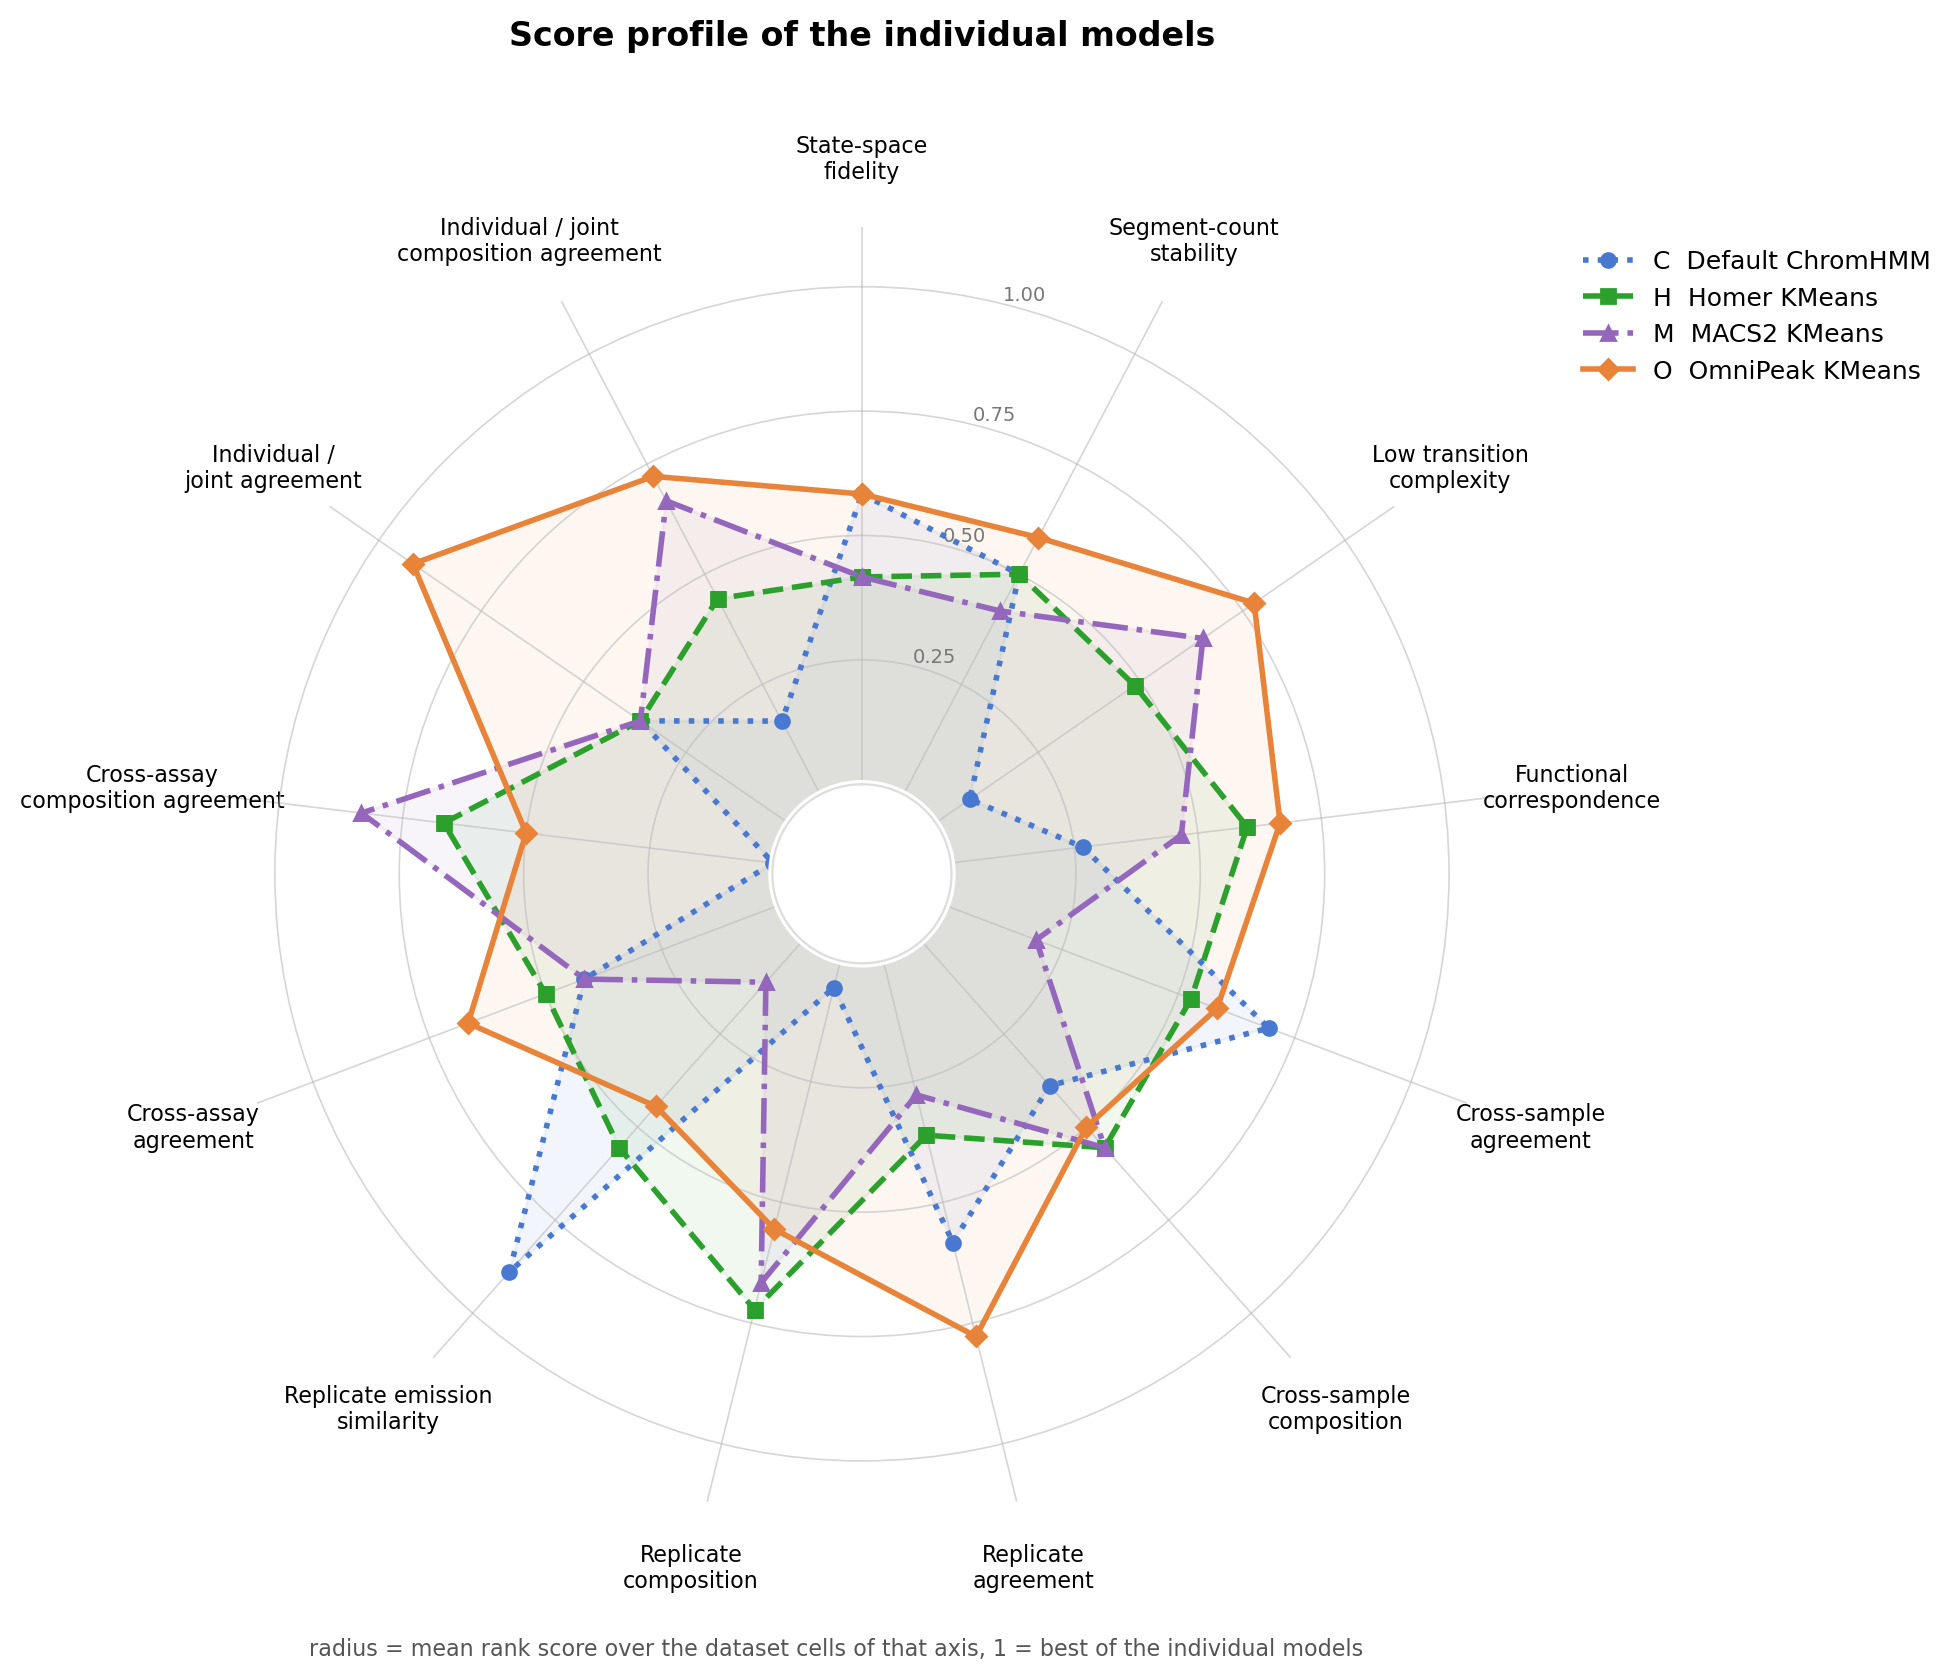

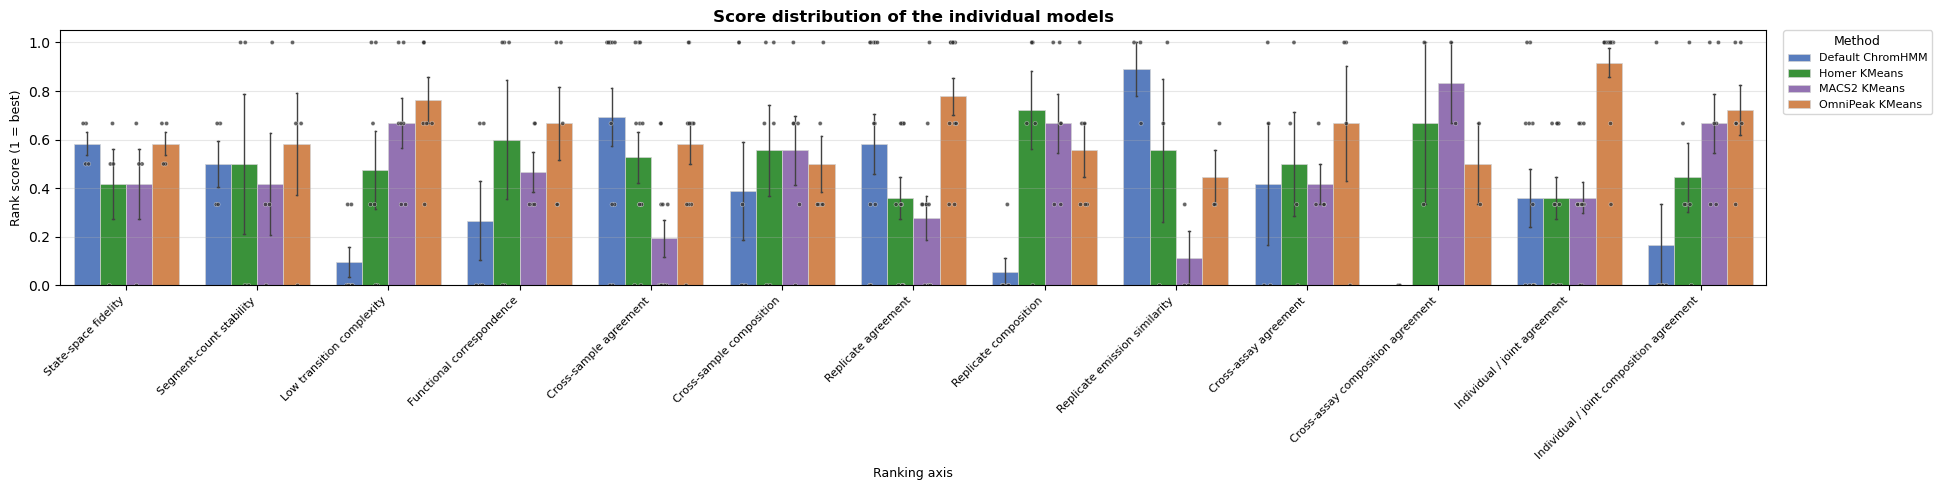

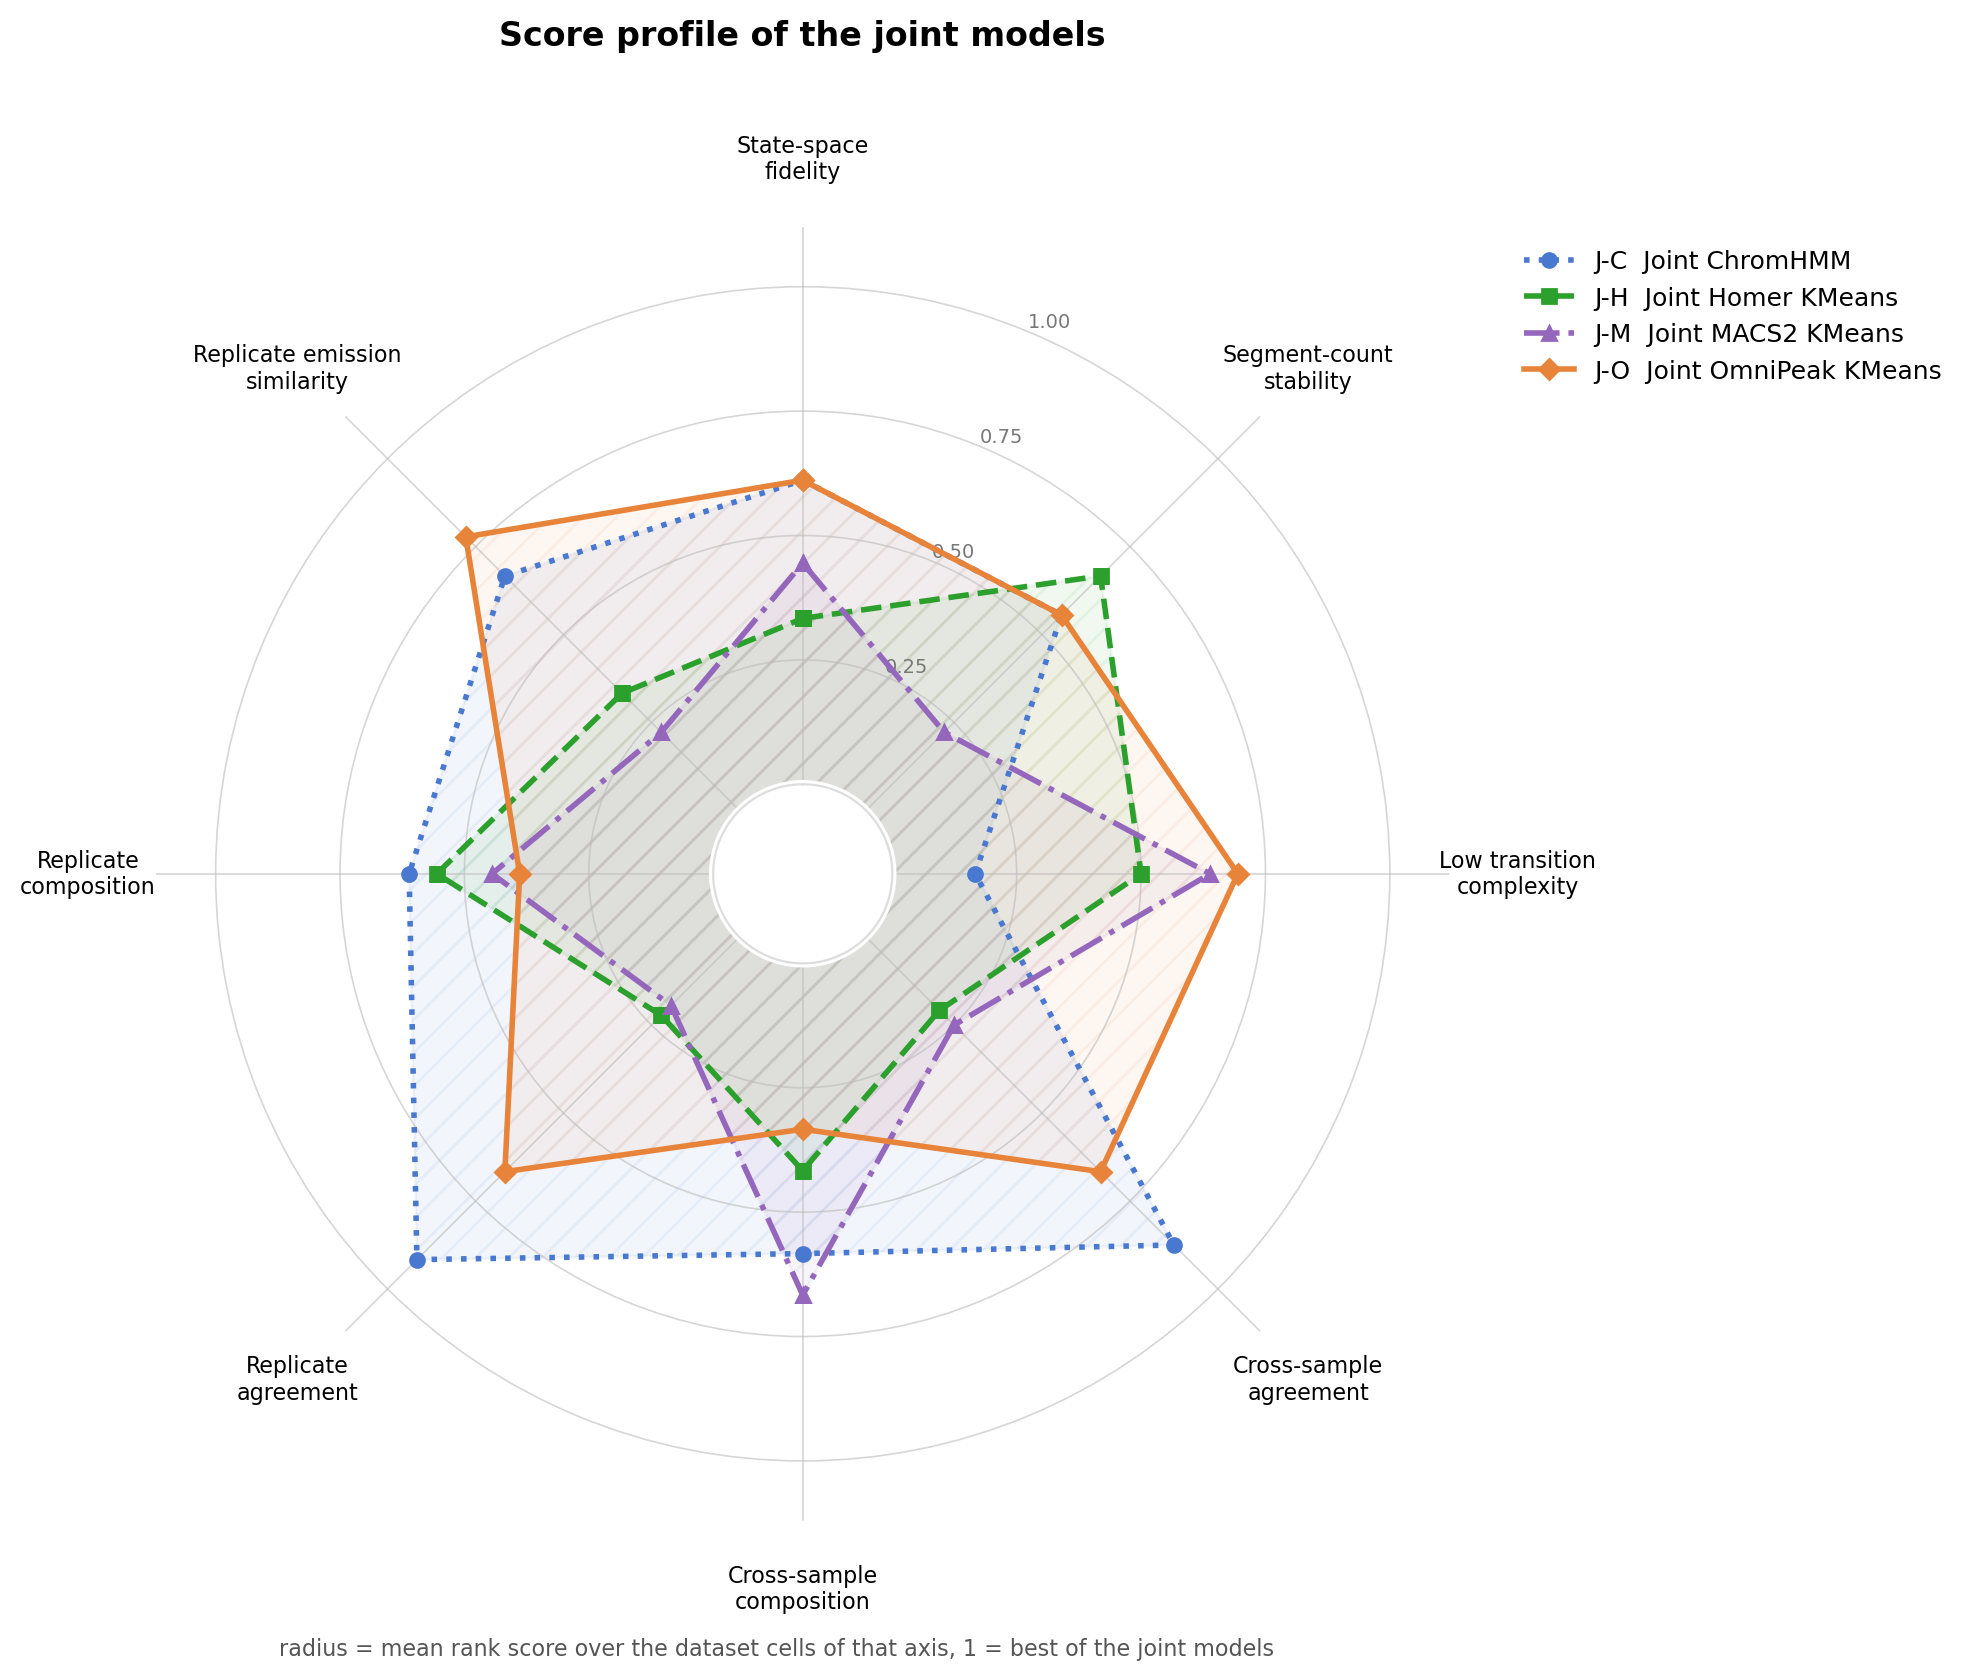

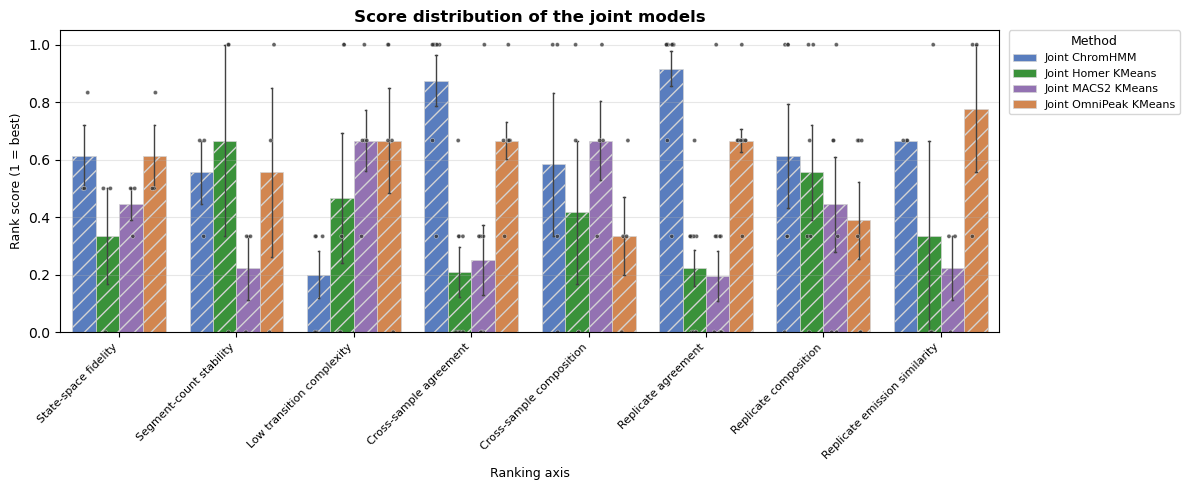

4

In [13]:
header("Score profiles")
show_all(["radar_individual.png", "radar_barplot_individual.png",
          "radar_joint.png", "radar_barplot_joint.png"],
         base=OUT, width=900)

,Rank,Method,Score,Axes,Datasets,Best axis,Worst axis
Method,,,,,,,
kmeans_omni,1,OmniPeak KMeans,0.637,13,3,Individual / joint agreement,Replicate emission similarity
kmeans_homer,2,Homer KMeans,0.515,13,3,Replicate composition,Replicate agreement
kmeans_macs2,3,MACS2 KMeans,0.464,13,3,Cross-assay composition agreement,Replicate emission similarity
chromhmm_default,4,Default ChromHMM,0.384,13,3,Replicate emission similarity,Cross-assay composition agreement


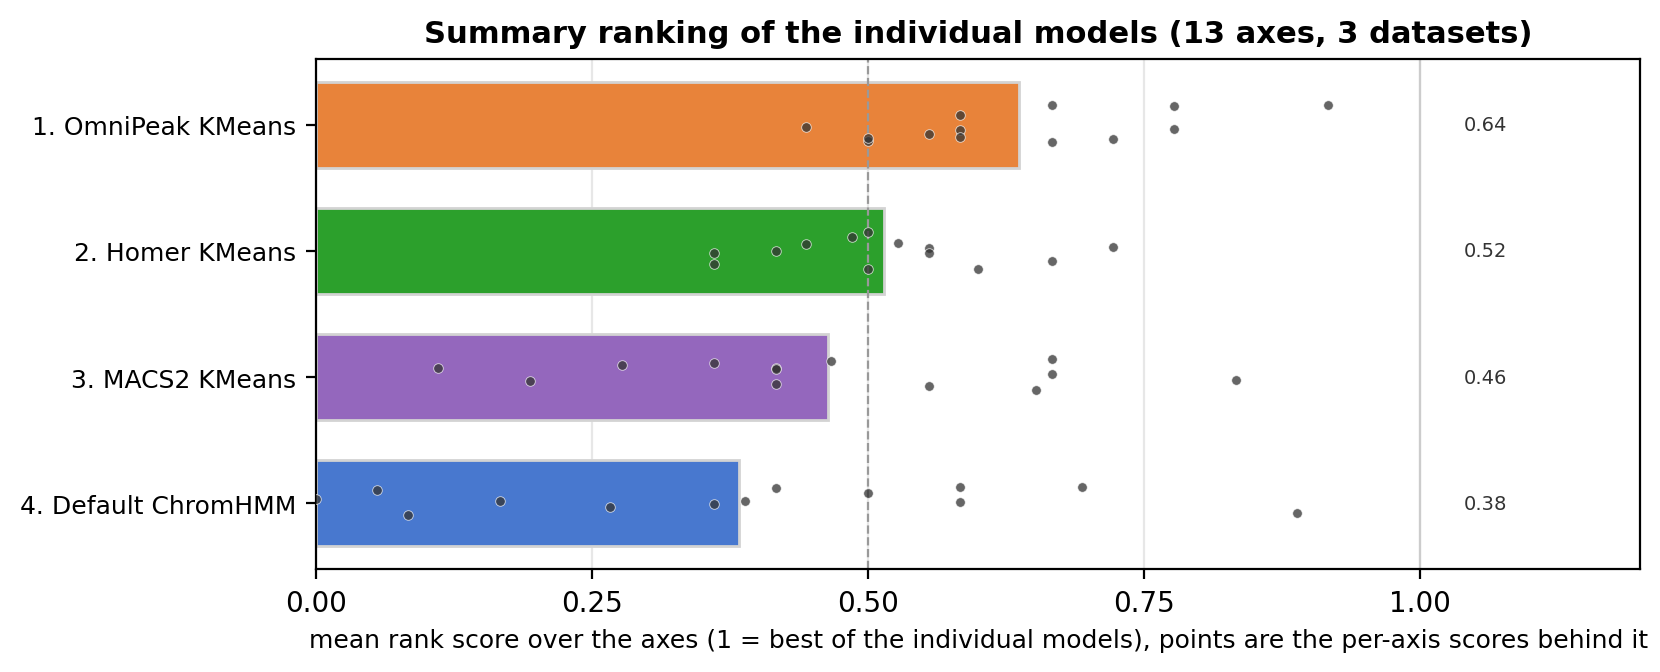

,Rank,Method,Score,Axes,Datasets,Best axis,Worst axis
Method,,,,,,,
joint_chromhmm,1,Joint ChromHMM,0.623,8,3,Replicate agreement,Low transition complexity
joint_kmeans_omni,2,Joint OmniPeak KMeans,0.587,8,3,Replicate emission similarity,Cross-sample composition
joint_kmeans_homer,3,Joint Homer KMeans,0.405,8,3,Segment-count stability,Cross-sample agreement
joint_kmeans_macs2,4,Joint MACS2 KMeans,0.385,8,3,Cross-sample composition,Replicate agreement


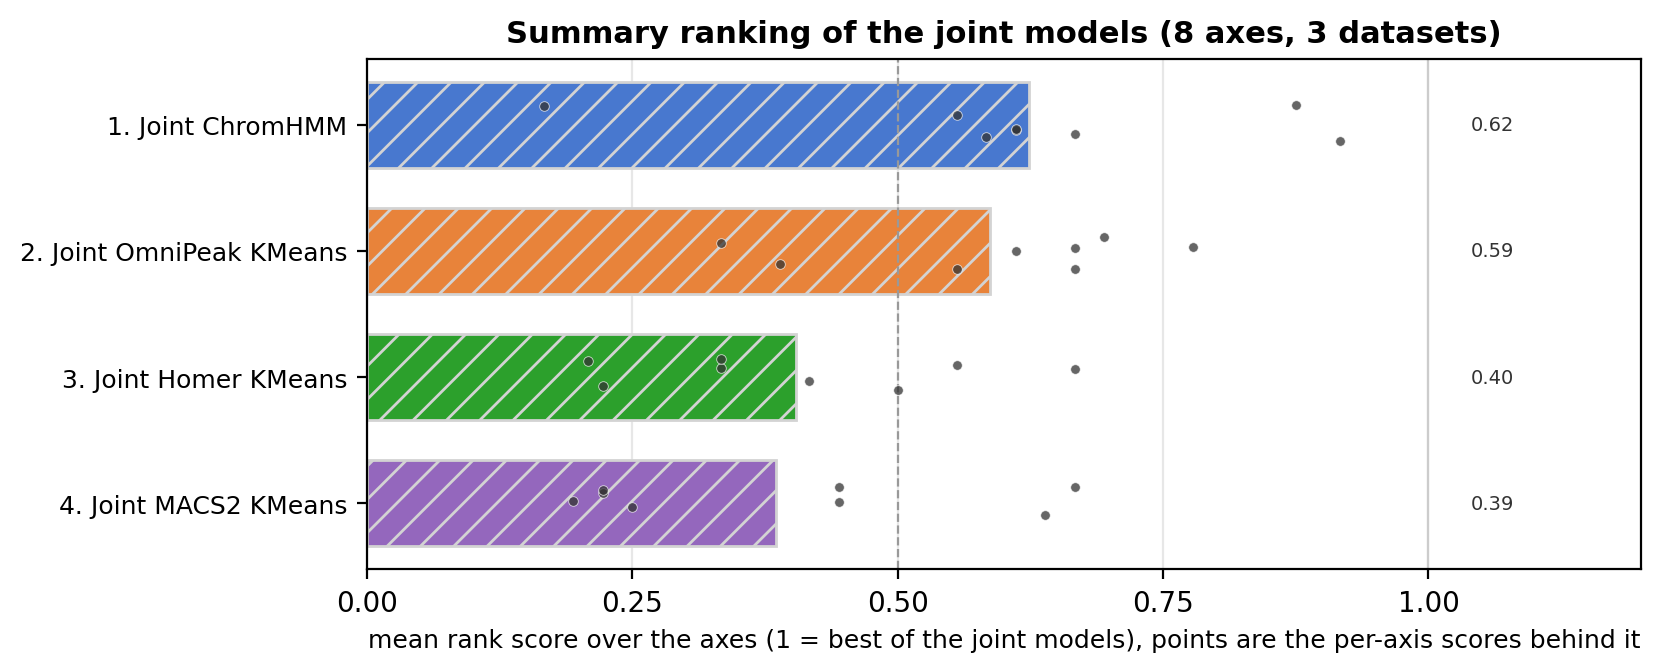

In [14]:
for group, ranking in [("individual", df_ranking_individual),
                       ("joint", df_ranking_joint)]:
    header(f"Summary ranking of the {group} models "
           f"({int(ranking['Axes'].max()) if not ranking.empty else 0} axes)")
    display(ranking.round(3))
    show_all([f"ranking_{group}.png"], base=OUT, width=820)